# Geopolitical Risk and the Real Economy: Industry-Level Evidence
## From Employment, Prices, and Output During the 2026 Strait of Hormuz Crisis

**Paper:** Examine how geopolitical risk shocks transmit to the US economy at the industry level, using the February 28, 2026 Iran conflict as a natural experiment.

**Data Sources (all free, no premium keys needed):**
- **FRED** — EPU index, oil prices, interest rates, macro indicators
- **yfinance** — Sector ETF daily prices (free, unlimited)
- **BLS** — Employment, CPI, PPI by industry
- **BEA** — GDP by industry
- **Treasury Fiscal Data** — Federal debt, spending

**Analysis:** Event Study, VAR/IRF, Granger Causality, Cross-sectional Regression

---

In [1]:
# ============================================================
# 1.1  Install dependencies
# ============================================================
!pip install pandas numpy requests matplotlib seaborn scipy statsmodels scikit-learn yfinance xlrd openpyxl -q

In [2]:
# ============================================================
# 1.2  Imports and configuration
# ============================================================
import pandas as pd
import numpy as np
import requests
import time
import warnings
import json
from datetime import datetime, timedelta
from io import StringIO

import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests, adfuller

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (14, 7), 'font.size': 12,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight'
})
sns.set_style("whitegrid")
print("All imports successful.")

All imports successful.


In [3]:
# ============================================================
# 1.3  API Keys and Configuration
#      ROBUST: SAMPLE_END = today's date (auto-updates on re-run)
# ============================================================
API_KEYS = {
    'FRED': '5f33ed2b539cfd80cd4a5343654a6fca',
    'BLS':  '5df8024e059b4966a66b69f1224259de',
    'BEA':  '94A4A4DE-3C3B-42F8-9204-6118E0A244DF',
}
# yfinance needs NO API key
# Treasury Fiscal Data needs NO API key

TREASURY_BASE = 'https://api.fiscaldata.treasury.gov/services/api/fiscal_service'

EVENT_DATE   = pd.Timestamp('2026-02-28')
SAMPLE_START = '2023-01-01'
SAMPLE_END   = pd.Timestamp('today').strftime('%Y-%m-%d')  # ← auto-updates
RUN_DATE     = pd.Timestamp('today')

# ── EXPANDED ETF UNIVERSE ──
# 11 GICS sector ETFs with S&P 500 weights (for Φ calculation)
GICS_SECTOR_ETFS = {
    'XLK':  ('Technology',               0.302),
    'XLF':  ('Financials',               0.133),
    'XLV':  ('Health Care',              0.117),
    'XLY':  ('Consumer Discretionary',   0.101),
    'XLC':  ('Communication Services',   0.089),
    'XLI':  ('Industrials',              0.083),
    'XLP':  ('Consumer Staples',         0.058),
    'XLE':  ('Energy',                   0.038),
    'XLRE': ('Real Estate',              0.024),
    'XLB':  ('Materials',                0.023),
    'XLU':  ('Utilities',                0.023),
}
# Normalize weights to sum to 1.0
_gw_sum = sum(w for _, w in GICS_SECTOR_ETFS.values())
GICS_WEIGHTS = {t: w / _gw_sum for t, (_, w) in GICS_SECTOR_ETFS.items()}

# ~25 sub-sector ETFs (for cross-sectional regression — no weights needed)
SUB_SECTOR_ETFS = {
    'USO':  'United States Oil Fund',
    'XOP':  'Oil & Gas Exploration',     'OIH':  'Oil Services',
    'AMLP': 'MLPs (Pipelines)',          'FCG':  'Natural Gas',
    'KRE':  'Regional Banks',            'KBE':  'Banks',
    'KIE':  'Insurance',                 'IAI':  'Broker-Dealers',
    'XHB':  'Homebuilders',              'ITB':  'Home Construction',
    'IYT':  'Transportation',            'JETS': 'Airlines',
    'XAR':  'Aerospace & Defense',       'ITA':  'Defense',
    'SMH':  'Semiconductors',            'IGV':  'Software',
    'XBI':  'Biotech',                   'IHF':  'Health Care Providers',
    'IBB':  'Biotech (Broad)',           'XRT':  'Retail',
    'HACK': 'Cybersecurity',             'TAN':  'Solar Energy',
    'URA':  'Uranium/Nuclear',           'REMX': 'Rare Earth',
}

# Liquidity filter threshold
ADDV_THRESHOLD = 10_000_000  # average daily dollar volume

# ETF data start — extended for placebos (Fix #12)
# USO structural break in Apr 2020 (Fix: Trap 3) — placebos restricted to post-Jun 2020
ETF_SAMPLE_START = '2018-01-01'
PLACEBO_START    = '2020-06-01'
PLACEBO_END      = '2025-12-31'
PLACEBO_MIN_GAP  = 15  # trading days between placebos (Fix #12)

# COVID dummy range for VARs (Fix #10)
COVID_START = pd.Timestamp('2020-03-01')
COVID_END   = pd.Timestamp('2020-08-01')

# MECE BLS sectors for Lilien index (Fix #11 + Trap 2)
# Excludes 'Total Private' (parent) and 'Retail Trade' (child of TTU)
LILIEN_SECTORS = [
    'Mining & Logging', 'Construction', 'Manufacturing',
    'Trade, Transport, Utilities', 'Information', 'Financial Activities',
    'Prof & Business Svcs', 'Education & Health', 'Leisure & Hospitality',
    'Other Services', 'Government',
]


def api_get(url, params=None, retries=3, delay=2):
    """GET with exponential backoff. Returns None on failure."""
    for attempt in range(retries):
        try:
            resp = requests.get(url, params=params, timeout=30)
            if resp.status_code == 400:
                print(f"  [400 Bad Request] — check series ID or params")
                return None
            resp.raise_for_status()
            return resp
        except requests.exceptions.RequestException as e:
            if attempt < retries - 1:
                wait = delay * (2 ** attempt)
                print(f"  Retry {attempt+1}/{retries} after {wait}s ...")
                time.sleep(wait)
            else:
                print(f"  FAILED after {retries} attempts: {e}")
                return None

def safe_float(val):
    try: return float(val)
    except (ValueError, TypeError): return np.nan

days_since_event = (RUN_DATE - EVENT_DATE).days
print(f"Run date:    {RUN_DATE.date()}")
print(f"Event date:  {EVENT_DATE.date()}")
print(f"Days since event: {days_since_event}")


# ============================================================
# 1.4  Data Caching via Google Drive
#      Mounts Drive and persists data across Colab sessions.
#      Cache lives in Drive/gpr_paper_cache/*.csv
#      Set CACHE_MAX_AGE_HOURS to control staleness threshold.
#      Set CACHE_MAX_AGE_HOURS = 0 to force re-fetch.
# ============================================================
import os

# ── Mount Google Drive (Colab only) ──
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    CACHE_DIR = '/content/drive/MyDrive/gpr_paper_cache'
    print(f"  Google Drive mounted — cache persists across sessions")
except ImportError:
    # Fallback for local runs (not Colab)
    CACHE_DIR = os.path.join(os.getcwd(), '.cache')
    print(f"  Not on Colab — using local cache")

os.makedirs(CACHE_DIR, exist_ok=True)

CACHE_MAX_AGE_HOURS = 24   # ← set to 0 to force re-fetch

_cache_meta_path = os.path.join(CACHE_DIR, '_cache_meta.json')

def _load_cache_meta():
    if os.path.exists(_cache_meta_path):
        with open(_cache_meta_path) as f:
            return json.load(f)
    return {}

def _save_cache_meta(meta):
    with open(_cache_meta_path, 'w') as f:
        json.dump(meta, f, indent=2, default=str)

def cache_is_fresh(key):
    """Check if a cached dataset exists and is younger than CACHE_MAX_AGE_HOURS."""
    if CACHE_MAX_AGE_HOURS <= 0:
        return False
    meta = _load_cache_meta()
    if key not in meta:
        return False
    cached_time = pd.Timestamp(meta[key]['saved_at'])
    age_hours = (pd.Timestamp('now') - cached_time).total_seconds() / 3600
    return age_hours < CACHE_MAX_AGE_HOURS

def save_to_cache(key, df, extra_info=None):
    """Save a DataFrame to CSV cache with metadata."""
    path = os.path.join(CACHE_DIR, f'{key}.csv')
    df.to_csv(path)
    meta = _load_cache_meta()
    meta[key] = {
        'saved_at': pd.Timestamp('now').isoformat(),
        'shape': list(df.shape),
        'sample_end': SAMPLE_END,
    }
    if extra_info:
        meta[key].update(extra_info)
    _save_cache_meta(meta)
    print(f"  [CACHE] Saved {key} → {path}  ({df.shape})")

def load_from_cache(key):
    """Load a DataFrame from CSV cache."""
    path = os.path.join(CACHE_DIR, f'{key}.csv')
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    meta = _load_cache_meta()
    info = meta.get(key, {})
    age = ''
    if 'saved_at' in info:
        hrs = (pd.Timestamp('now') - pd.Timestamp(info['saved_at'])).total_seconds() / 3600
        age = f' ({hrs:.1f}h old)'
    print(f"  [CACHE] Loaded {key}{age}  {df.shape}")
    return df

print(f"Cache dir:   {CACHE_DIR}")
print(f"Cache TTL:   {CACHE_MAX_AGE_HOURS}h (set CACHE_MAX_AGE_HOURS=0 to force refresh)")

Run date:    2026-03-18
Event date:  2026-02-28
Days since event: 18
Mounted at /content/drive
  Google Drive mounted — cache persists across sessions
Cache dir:   /content/drive/MyDrive/gpr_paper_cache
Cache TTL:   24h (set CACHE_MAX_AGE_HOURS=0 to force refresh)


---
## Section 2: Data Collection

In [4]:
# ============================================================
# 2.1  FRED — Macro Indicators  [CACHED]
#      FIX: Replaced GPRH with USEPUINDXD (Economic Policy
#           Uncertainty Index, daily). GPR index is NOT on FRED.
# ============================================================
def fetch_fred(series_id, start=SAMPLE_START, end=SAMPLE_END):
    url = 'https://api.stlouisfed.org/fred/series/observations'
    params = {
        'series_id': series_id, 'api_key': API_KEYS['FRED'],
        'file_type': 'json',
        'observation_start': start, 'observation_end': end,
    }
    resp = api_get(url, params=params)
    if resp is None:
        return pd.Series(dtype=float, name=series_id)
    obs = resp.json().get('observations', [])
    if not obs:
        return pd.Series(dtype=float, name=series_id)
    df = pd.DataFrame(obs)
    df['date'] = pd.to_datetime(df['date'])
    df['value'] = df['value'].apply(safe_float)
    s = df.set_index('date')['value'].dropna()
    s.name = series_id
    return s

# --- Daily series ---
FRED_DAILY = {
    'USEPUINDXD':   'Economic Policy Uncertainty (Daily)',
    'DCOILWTICO':   'WTI Crude Oil ($/barrel)',
    'DCOILBRENTEU': 'Brent Crude Oil ($/barrel)',
    'DFF':          'Fed Funds Rate (%)',
    'DGS10':        '10-Year Treasury Yield (%)',
    'VIXCLS':       'VIX Index',
    'DTWEXBGS':     'USD Trade-Weighted Index',
}
# --- Monthly series ---
FRED_MONTHLY = {
    'USEPUINDXM': 'Economic Policy Uncertainty (Monthly)',
    'UMCSENT':    'Consumer Sentiment (Michigan)',
    'UNRATE':     'Unemployment Rate (%)',
    'CPIAUCSL':   'CPI All Urban Consumers',
    'INDPRO':     'Industrial Production Index',
}

if cache_is_fresh('fred_daily') and cache_is_fresh('fred_monthly'):
    fred_daily_df = load_from_cache('fred_daily')
    fred_monthly_df = load_from_cache('fred_monthly')
else:
    print("Fetching FRED daily series ...")
    fred_daily = {}
    for sid, label in FRED_DAILY.items():
        print(f"  {sid}: {label}", end=" ... ")
        s = fetch_fred(sid)
        fred_daily[sid] = s
        print(f"{len(s)} obs" if len(s) else "NO DATA")
        time.sleep(0.3)

    fred_daily_df = pd.DataFrame(fred_daily)
    fred_daily_df.index = pd.to_datetime(fred_daily_df.index)
    fred_daily_df = fred_daily_df.sort_index()
    save_to_cache('fred_daily', fred_daily_df)

    print("\nFetching FRED monthly series ...")
    fred_monthly = {}
    for sid, label in FRED_MONTHLY.items():
        print(f"  {sid}: {label}", end=" ... ")
        s = fetch_fred(sid)
        fred_monthly[sid] = s
        print(f"{len(s)} obs" if len(s) else "NO DATA")
        time.sleep(0.3)

    fred_monthly_df = pd.DataFrame(fred_monthly)
    fred_monthly_df.index = pd.to_datetime(fred_monthly_df.index)
    fred_monthly_df = fred_monthly_df.sort_index()
    save_to_cache('fred_monthly', fred_monthly_df)

print(f"\nFRED daily: {fred_daily_df.shape}")
print(f"FRED monthly: {fred_monthly_df.shape}")
display(fred_daily_df.tail())
display(fred_monthly_df.tail())

  [CACHE] Loaded fred_daily (0.3h old)  (1171, 7)
  [CACHE] Loaded fred_monthly (0.3h old)  (38, 5)

FRED daily: (1171, 7)
FRED monthly: (38, 5)


,USEPUINDXD,DCOILWTICO,DCOILBRENTEU,DFF,DGS10,VIXCLS,DTWEXBGS
date,,,,,,,
2026-03-12,350.84,NaN,NaN,3.64,4.27,27.29,119.8227
2026-03-13,472.52,NaN,NaN,3.64,4.28,27.19,120.5518
2026-03-14,449.72,NaN,NaN,3.64,NaN,NaN,NaN
2026-03-15,511.93,NaN,NaN,3.64,NaN,NaN,NaN
2026-03-16,263.43,NaN,NaN,3.64,4.23,23.51,NaN


,USEPUINDXM,UMCSENT,UNRATE,CPIAUCSL,INDPRO
date,,,,,
2025-10-01,217.50844,53.6,NaN,NaN,101.2075
2025-11-01,218.76604,51.0,4.5,325.063,101.3605
2025-12-01,205.27646,52.9,4.4,326.031,101.6781
2026-01-01,253.68826,56.4,4.3,326.588,102.3963
2026-02-01,262.26624,NaN,4.4,327.460,102.5510


In [5]:
# ============================================================
# 2.2  yfinance — Sector ETFs  [CACHED]
#      EXPANDED: 11 GICS sectors + SPY + ~25 sub-sectors + USO
#      Data from 2018 for placebo tests (Fix #12)
# ============================================================
SECTOR_ETFS = {
    'SPY':  'S&P 500 (Market)',
    'XLE':  'Energy',          'XLF':  'Financials',
    'XLI':  'Industrials',     'XLK':  'Technology',
    'XLV':  'Health Care',     'XLC':  'Communication Services',
    'XLB':  'Materials',       'XLRE': 'Real Estate',
    'XLU':  'Utilities',       'XLP':  'Consumer Staples',
    'XLY':  'Consumer Discretionary',
}

# Combined universe (deduplicated)
ALL_ETFS = {**SECTOR_ETFS, **SUB_SECTOR_ETFS}
ALL_TICKERS = list(ALL_ETFS.keys())

if cache_is_fresh('etf_prices_expanded'):
    etf_df = load_from_cache('etf_prices_expanded')
else:
    print(f"Downloading {len(ALL_TICKERS)} ETFs via yfinance (from {ETF_SAMPLE_START}) ...")
    raw = yf.download(ALL_TICKERS, start=ETF_SAMPLE_START, end=SAMPLE_END, progress=True)

    if isinstance(raw.columns, pd.MultiIndex):
        etf_df = raw['Close'].copy()
    else:
        etf_df = raw[['Close']].copy()
        etf_df.columns = ALL_TICKERS

    etf_df.index = pd.to_datetime(etf_df.index)
    etf_df = etf_df.sort_index()
    save_to_cache('etf_prices_expanded', etf_df)

print(f"\nETF data: {etf_df.shape[0]} trading days, {etf_df.shape[1]} ETFs")
print(f"Date range: {etf_df.index.min().date()} to {etf_df.index.max().date()}")
print(f"GICS sectors: {sum(1 for t in GICS_WEIGHTS if t in etf_df.columns)}/11")
print(f"Sub-sectors:  {sum(1 for t in SUB_SECTOR_ETFS if t in etf_df.columns)}/{len(SUB_SECTOR_ETFS)}")
display(etf_df.tail())

  [CACHE] Loaded etf_prices_expanded (0.3h old)  (2062, 37)

ETF data: 2062 trading days, 37 ETFs
Date range: 2018-01-02 to 2026-03-17
GICS sectors: 11/11
Sub-sectors:  25/25


,AMLP,FCG,HACK,IAI,IBB,IGV,IHF,ITA,ITB,IYT,...,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY,XOP,XRT
Date,,,,,,,,,,,,,,,,,,,,,
2026-03-11,52.410000,29.110001,78.440002,164.788818,170.745270,85.739998,44.010242,238.525177,95.177940,75.506950,...,49.639999,169.490005,140.429993,84.589996,42.410000,46.169998,152.850006,114.139999,164.690002,81.739998
2026-03-12,52.060001,29.379999,77.970001,160.696243,166.108658,84.989998,43.252647,231.339859,92.463135,72.946205,...,48.830002,165.240005,137.839996,84.250000,42.139999,46.500000,150.160004,111.519997,166.710007,80.260002
2026-03-13,52.209999,29.709999,77.910004,161.303650,165.389191,84.190002,43.551697,229.191238,92.902290,72.996033,...,48.889999,164.649994,136.800003,84.739998,42.250000,46.959999,149.789993,110.860001,167.889999,80.019997
2026-03-16,52.310001,29.730000,76.870003,162.866989,167.018005,84.949997,43.771000,232.658997,94.099998,73.833000,...,49.299999,166.059998,138.779999,84.980003,42.580002,47.259998,151.009995,112.199997,167.369995,80.169998
2026-03-17,52.660000,30.080000,77.550003,164.970001,167.169998,85.529999,43.799999,232.899994,94.230003,75.099998,...,49.560001,166.500000,139.539993,84.699997,42.720001,47.130001,149.639999,113.180000,170.080002,80.360001


In [6]:
# ============================================================
# 2.3  BLS — Employment, CPI, PPI by Industry  [CACHED]
# ============================================================
def fetch_bls(series_ids, start_year=2015, end_year=2026):
    url = 'https://api.bls.gov/publicAPI/v2/timeseries/data/'
    headers = {'Content-type': 'application/json'}
    payload = json.dumps({
        'seriesid': series_ids,
        'startyear': str(start_year), 'endyear': str(end_year),
        'registrationkey': API_KEYS['BLS'],
    })
    resp = requests.post(url, data=payload, headers=headers, timeout=30)
    if resp.status_code != 200:
        print(f"  [ERROR] BLS API {resp.status_code}")
        return {}
    result = resp.json()
    if result.get('status') != 'REQUEST_SUCCEEDED':
        print(f"  [ERROR] BLS: {result.get('message', '')[:80]}")
        return {}
    out = {}
    for sd in result.get('Results', {}).get('series', []):
        sid = sd['seriesID']
        recs = []
        for obs in sd.get('data', []):
            per = obs['period']
            if not per.startswith('M'): continue
            dt = pd.Timestamp(year=int(obs['year']), month=int(per[1:]), day=1)
            recs.append({'date': dt, 'value': safe_float(obs['value'])})
        if recs:
            s = pd.DataFrame(recs).set_index('date')['value'].sort_index()
            s.name = sid
            out[sid] = s
    return out

CES_EMP = {
    'CES0500000001': 'Total Private',
    'CES1000000001': 'Mining & Logging',
    'CES2000000001': 'Construction',
    'CES3000000001': 'Manufacturing',
    'CES4000000001': 'Trade, Transport, Utilities',
    'CES4142000001': 'Retail Trade',
    'CES5000000001': 'Information',
    'CES5500000001': 'Financial Activities',
    'CES6000000001': 'Prof & Business Svcs',
    'CES6500000001': 'Education & Health',
    'CES7000000001': 'Leisure & Hospitality',
    'CES8000000001': 'Other Services',
    'CES9000000001': 'Government',
}
CPI_COMP = {
    'CUSR0000SA0':  'CPI All Items',    'CUSR0000SA0E': 'CPI Energy',
    'CUSR0000SAF1': 'CPI Food',         'CUSR0000SAH1': 'CPI Shelter',
    'CUSR0000SAM':  'CPI Medical',      'CUSR0000SAT1': 'CPI Transport',
    'CUSR0000SAA':  'CPI Apparel',
}
PPI_IND = {
    'PCU2111--2111--': 'PPI Oil & Gas',  'PCU325---325---': 'PPI Chemicals',
    'PCU333---333---': 'PPI Machinery',  'PCU336---336---': 'PPI Transport Equip',
    'PCU221---221---': 'PPI Utilities',  'PCU484---484---': 'PPI Truck Transport',
}

if cache_is_fresh('ces_employment') and cache_is_fresh('cpi_components') and cache_is_fresh('ppi_industry'):
    ces_df = load_from_cache('ces_employment')
    cpi_df = load_from_cache('cpi_components')
    ppi_df = load_from_cache('ppi_industry')
else:
    print("Fetching BLS Employment ...")
    ces_s = fetch_bls(list(CES_EMP.keys()))
    ces_df = pd.DataFrame(ces_s)
    ces_df.columns = [CES_EMP.get(c, c) for c in ces_df.columns]
    print(f"  Employment: {ces_df.shape}")
    save_to_cache('ces_employment', ces_df)

    time.sleep(1)
    print("Fetching BLS CPI ...")
    cpi_s = fetch_bls(list(CPI_COMP.keys()))
    cpi_df = pd.DataFrame(cpi_s)
    cpi_df.columns = [CPI_COMP.get(c, c) for c in cpi_df.columns]
    print(f"  CPI: {cpi_df.shape}")
    save_to_cache('cpi_components', cpi_df)

    time.sleep(1)
    print("Fetching BLS PPI ...")
    ppi_s = fetch_bls(list(PPI_IND.keys()))
    ppi_df = pd.DataFrame(ppi_s)
    ppi_df.columns = [PPI_IND.get(c, c) for c in ppi_df.columns]
    print(f"  PPI: {ppi_df.shape}")
    save_to_cache('ppi_industry', ppi_df)

display(ces_df.tail(3))
display(cpi_df.tail(3))

  [CACHE] Loaded ces_employment (0.3h old)  (134, 13)
  [CACHE] Loaded cpi_components (0.3h old)  (134, 7)
  [CACHE] Loaded ppi_industry (0.3h old)  (133, 6)


,Total Private,Mining & Logging,Construction,Manufacturing,"Trade, Transport, Utilities",Retail Trade,Information,Financial Activities,Prof & Business Svcs,Education & Health,Leisure & Hospitality,Other Services,Government
date,,,,,,,,,,,,,
2025-12-01,135083.0,604.0,8272.0,12580.0,28616.0,6042.5,2842.0,9186.0,22372.0,27627.0,16961.0,6023.0,23349.0
2026-01-01,135229.0,602.0,8320.0,12585.0,28617.0,6045.0,2823.0,9156.0,22390.0,27756.0,16949.0,6031.0,23329.0
2026-02-01,135143.0,600.0,8309.0,12573.0,28615.0,6051.0,2812.0,9166.0,22385.0,27722.0,16922.0,6039.0,23323.0


,CPI All Items,CPI Energy,CPI Food,CPI Shelter,CPI Medical,CPI Transport,CPI Apparel
date,,,,,,,
2025-12-01,326.031,285.624,344.632,421.039,588.092,273.841,132.317
2026-01-01,326.588,281.436,345.271,421.965,589.610,271.780,132.723
2026-02-01,327.460,283.223,346.622,422.942,592.554,272.133,134.419


In [7]:
# ============================================================
# 2.4  BEA — GDP by Industry (Quarterly)  [CACHED]
# ============================================================
def fetch_bea_gdp():
    url = 'https://apps.bea.gov/api/data/'
    params = {
        'UserID': API_KEYS['BEA'], 'method': 'GetData',
        'DatasetName': 'GDPByIndustry', 'TableID': '1',
        'Frequency': 'Q',
        'Year': ','.join([str(y) for y in range(2023, 2027)]),
        'Industry': 'ALL', 'ResultFormat': 'JSON',
    }
    resp = api_get(url, params=params)
    if resp is None: return pd.DataFrame()
    data = resp.json()
    results = data.get('BEAAPI', {}).get('Results', {})
    if isinstance(results, list): results = results[0] if results else {}
    rows = results.get('Data', [])
    if not rows: return pd.DataFrame()

    q_map = {'I':1,'II':4,'III':7,'IV':10,'1':1,'2':4,'3':7,'4':10}
    recs = []
    for r in rows:
        try:
            yr = int(r.get('Year', 0))
            qs = r.get('Quarter', '').replace('Q','')
            mo = q_map.get(qs)
            if mo is None: continue
            recs.append({
                'date': pd.Timestamp(year=yr, month=mo, day=1),
                'industry': r.get('IndustryDescription', ''),
                'gdp': safe_float(str(r.get('DataValue','')).replace(',',''))
            })
        except: continue
    return pd.DataFrame(recs) if recs else pd.DataFrame()

if cache_is_fresh('bea_gdp'):
    bea_df = load_from_cache('bea_gdp')
    print(f"  BEA: {bea_df.shape[1]} industries, {bea_df.shape[0]} quarters")
else:
    print("Fetching BEA GDP by Industry ...")
    bea_raw = fetch_bea_gdp()
    if not bea_raw.empty:
        bea_df = bea_raw.pivot_table(index='date', columns='industry', values='gdp', aggfunc='first').sort_index()
        print(f"  BEA: {bea_df.shape[1]} industries, {bea_df.shape[0]} quarters")
        save_to_cache('bea_gdp', bea_df)
    else:
        bea_df = pd.DataFrame()
        print("  BEA: no data returned")

  [CACHE] Loaded bea_gdp (0.3h old)  (11, 1)
  BEA: 1 industries, 11 quarters


In [8]:
# ============================================================
# 2.5  Treasury Fiscal Data — Debt to the Penny  [CACHED]
#      FIX: Removed MTS table 5 (wrong field names). Debt data
#           is the most relevant fiscal variable for this paper.
# ============================================================
if cache_is_fresh('treasury_debt'):
    treasury_debt = load_from_cache('treasury_debt')
    print(f"  Debt: {treasury_debt.shape[0]} observations")
else:
    print("Fetching Treasury Debt to the Penny ...")
    url = f"{TREASURY_BASE}/v2/accounting/od/debt_to_penny"
    params = {
        'fields': 'record_date,tot_pub_debt_out_amt',
        'filter': f'record_date:gte:{SAMPLE_START},record_date:lte:{SAMPLE_END}',
        'sort': '-record_date', 'page[size]': 1000,
    }
    resp = api_get(url, params=params)
    if resp is not None:
        rows = resp.json().get('data', [])
        treasury_debt = pd.DataFrame(rows)
        treasury_debt['record_date'] = pd.to_datetime(treasury_debt['record_date'])
        treasury_debt = treasury_debt.set_index('record_date').sort_index()
        treasury_debt['tot_pub_debt_out_amt'] = treasury_debt['tot_pub_debt_out_amt'].apply(safe_float)
        save_to_cache('treasury_debt', treasury_debt)
        print(f"  Debt: {treasury_debt.shape[0]} observations")
    else:
        treasury_debt = pd.DataFrame()
        print("  Treasury: no data")

if not treasury_debt.empty:
    print(f"  Latest: ${treasury_debt['tot_pub_debt_out_amt'].iloc[-1]/1e12:.2f} trillion")
    display(treasury_debt.tail())

  [CACHE] Loaded treasury_debt (0.3h old)  (801, 1)
  Debt: 801 observations
  Latest: $38.99 trillion


,tot_pub_debt_out_amt
record_date,
2026-03-10,3.891886e+13
2026-03-11,3.888242e+13
2026-03-12,3.890088e+13
2026-03-13,3.890264e+13
2026-03-16,3.899219e+13


---
## Section 3: Data Processing

In [9]:
# ============================================================
# 3.1  ETF Daily Log Returns
# ============================================================
etf_returns = np.log(etf_df / etf_df.shift(1)).dropna()
print(f"ETF returns: {etf_returns.shape[0]} days, {etf_returns.shape[1]} ETFs")

summary = etf_returns.describe().T
summary['skew'] = etf_returns.skew()
summary['kurt'] = etf_returns.kurtosis()
display(summary[['mean','std','min','max','skew','kurt']].round(4))

ETF returns: 1945 days, 37 ETFs


,mean,std,min,max,skew,kurt
AMLP,0.0004,0.0195,-0.3299,0.1357,-3.3343,56.6935
FCG,0.0003,0.0261,-0.3362,0.1365,-0.9638,16.3980
HACK,0.0004,0.0153,-0.1117,0.1080,-0.4060,4.9245
IAI,0.0005,0.0153,-0.1410,0.1147,-0.6166,12.7990
IBB,0.0002,0.0150,-0.0939,0.0707,-0.2261,2.9419
IGV,0.0004,0.0177,-0.1252,0.1102,-0.2934,4.0450
IHF,0.0002,0.0143,-0.1635,0.0849,-1.0582,15.2347
ITA,0.0005,0.0158,-0.1595,0.1160,-0.7491,14.4440
ITB,0.0005,0.0205,-0.2256,0.1540,-0.5662,12.7202
IYT,0.0003,0.0156,-0.1173,0.1223,-0.2754,9.0763


In [10]:
# ============================================================
# 3.1a  Liquidity Filter — ADDV > $10M  (Fix #2)
#       Filters ETFs by Average Daily Dollar Volume in the
#       estimation window [-250, -11] relative to event.
# ============================================================
# We need volume data — re-download just volume for our universe
if cache_is_fresh('etf_volume'):
    etf_volume = load_from_cache('etf_volume')
else:
    print("Downloading volume data ...")
    raw_vol = yf.download(ALL_TICKERS, start=ETF_SAMPLE_START, end=SAMPLE_END, progress=False)
    if isinstance(raw_vol.columns, pd.MultiIndex):
        etf_volume = raw_vol['Volume'].copy()
    else:
        etf_volume = raw_vol[['Volume']].copy()
    etf_volume.index = pd.to_datetime(etf_volume.index)
    save_to_cache('etf_volume', etf_volume)

# Compute ADDV in estimation window
trading_days_all = etf_returns.index.sort_values()
evt_idx = trading_days_all.searchsorted(EVENT_DATE)
if evt_idx >= len(trading_days_all):
    evt_idx = len(trading_days_all) - 1
est_start_idx = max(0, evt_idx - 250)
est_end_idx   = max(0, evt_idx - 11)
est_dates = trading_days_all[est_start_idx:est_end_idx + 1]

addv = {}
for ticker in etf_df.columns:
    if ticker in etf_volume.columns and ticker in etf_df.columns:
        price = etf_df[ticker].reindex(est_dates)
        vol   = etf_volume[ticker].reindex(est_dates)
        dv = (price * vol).dropna()
        addv[ticker] = dv.mean() if len(dv) > 20 else 0

addv_df = pd.Series(addv, name='ADDV').sort_values(ascending=False)
passed = addv_df[addv_df >= ADDV_THRESHOLD].index.tolist()
failed = addv_df[addv_df < ADDV_THRESHOLD].index.tolist()

# Always keep SPY
if 'SPY' not in passed:
    passed.insert(0, 'SPY')

print(f"Liquidity filter: ADDV > ${ADDV_THRESHOLD/1e6:.0f}M in estimation window")
print(f"Passed: {len(passed)}/{len(addv_df)} ETFs")
if failed:
    print(f"Dropped: {failed}")
print(f"\nTop 10 by ADDV:")
display(addv_df.head(10).apply(lambda x: f"${x/1e6:.1f}M"))

# Filtered returns for event study and cross-section
filtered_returns = etf_returns[[c for c in passed if c in etf_returns.columns]]
print(f"\nFiltered returns: {filtered_returns.shape[0]} days × {filtered_returns.shape[1]} ETFs")

  [CACHE] Loaded etf_volume (0.3h old)  (2062, 37)
Liquidity filter: ADDV > $10M in estimation window
Passed: 36/37 ETFs
Dropped: ['HACK']

Top 10 by ADDV:


,ADDV
SPY,$48735.1M
SMH,$2353.0M
XLF,$2219.1M
XLK,$2013.6M
XLV,$1759.9M
XLI,$1608.4M
XLE,$1583.9M
XLP,$1255.0M
XLY,$1200.2M
XBI,$1007.1M



Filtered returns: 1945 days × 36 ETFs


In [11]:
# ============================================================
# 3.1b  Partial Beta Estimation — Two-Factor Model  (Fix #2, #5, #9)
#       R_i = α + β_mkt·R_SPY + β_oil·R_USO + ε
#       Uses USO (not FRED WTI) for exact date alignment.
#       Estimation window: [-250, -11] relative to event.
# ============================================================
def estimate_two_factor_betas(returns_df, market='SPY', oil='USO',
                               est_dates=None):
    """Two-factor model: market + oil. Returns beta_mkt, beta_oil per ETF."""
    mkt_ret = returns_df[market].reindex(est_dates).dropna()
    oil_ret = returns_df[oil].reindex(est_dates).dropna() if oil in returns_df.columns else None

    if oil_ret is None or len(oil_ret) < 30:
        print("[WARN] USO not available — falling back to single-factor model")
        oil_ret = None

    sectors = [c for c in returns_df.columns if c not in (market, oil)]
    results = []

    for sec in sectors:
        sec_ret = returns_df[sec].reindex(est_dates).dropna()
        common_idx = mkt_ret.index.intersection(sec_ret.index)
        if oil_ret is not None:
            common_idx = common_idx.intersection(oil_ret.index)
        if len(common_idx) < 60:
            continue

        y = sec_ret.loc[common_idx].values
        if oil_ret is not None:
            X = np.column_stack([
                np.ones(len(common_idx)),
                mkt_ret.loc[common_idx].values,
                oil_ret.loc[common_idx].values,
            ])
            # numpy lstsq — fast, no statsmodels overhead (Trap 1 prep)
            coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
            alpha, beta_mkt, beta_oil = coeffs

            # Compute t-stats manually
            resid = y - X @ coeffs
            sigma2 = np.sum(resid**2) / (len(y) - 3)
            se = np.sqrt(np.diag(sigma2 * np.linalg.inv(X.T @ X)))
            t_mkt = beta_mkt / se[1]
            t_oil = beta_oil / se[2]
            r2 = 1 - np.sum(resid**2) / np.sum((y - y.mean())**2)
        else:
            X = np.column_stack([np.ones(len(common_idx)), mkt_ret.loc[common_idx].values])
            coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
            alpha, beta_mkt = coeffs
            beta_oil, t_oil = np.nan, np.nan
            resid = y - X @ coeffs
            sigma2 = np.sum(resid**2) / (len(y) - 2)
            se = np.sqrt(np.diag(sigma2 * np.linalg.inv(X.T @ X)))
            t_mkt = beta_mkt / se[1]
            r2 = 1 - np.sum(resid**2) / np.sum((y - y.mean())**2)

        results.append({
            'ticker': sec,
            'name': ALL_ETFS.get(sec, sec),
            'beta_mkt': beta_mkt,
            'beta_oil': beta_oil,
            't_mkt': t_mkt,
            't_oil': t_oil,
            'r2': r2,
            'n_obs': len(common_idx),
        })

    return pd.DataFrame(results).set_index('ticker')

beta_df = estimate_two_factor_betas(filtered_returns, est_dates=est_dates)
print(f"Two-factor betas estimated for {len(beta_df)} ETFs")
print(f"Estimation window: {est_dates[0].date()} to {est_dates[-1].date()}")
print(f"\nSorted by β_oil (partial oil sensitivity, net of market):")
display(beta_df.sort_values('beta_oil', ascending=False)[
    ['name', 'beta_mkt', 'beta_oil', 't_oil', 'r2']
].round(3))

Two-factor betas estimated for 34 ETFs
Estimation window: 2025-03-03 to 2026-02-12

Sorted by β_oil (partial oil sensitivity, net of market):


,name,beta_mkt,beta_oil,t_oil,r2
ticker,,,,,
FCG,Natural Gas,0.739,0.620,15.854,0.695
XOP,Oil & Gas Exploration,0.830,0.617,16.115,0.721
OIH,Oil Services,1.096,0.550,11.272,0.652
XLE,Energy,0.584,0.460,14.659,0.671
AMLP,MLPs (Pipelines),0.447,0.182,7.274,0.502
REMX,Rare Earth,1.038,0.075,0.867,0.210
ITA,Defense,0.835,0.067,2.060,0.555
XAR,Aerospace & Defense,0.991,0.064,1.594,0.529
TAN,Solar Energy,0.984,0.053,0.746,0.258


In [12]:
# ============================================================
# 3.2  Monthly % Changes for Real Economy Data
# ============================================================
emp_growth = ces_df.pct_change() * 100 if not ces_df.empty else pd.DataFrame()
cpi_inflation = cpi_df.pct_change() * 100 if not cpi_df.empty else pd.DataFrame()
ppi_change = ppi_df.pct_change() * 100 if not ppi_df.empty else pd.DataFrame()

print(f"Employment growth:  {emp_growth.shape}")
print(f"CPI inflation:      {cpi_inflation.shape}")
print(f"PPI change:         {ppi_change.shape}")

if not emp_growth.empty:
    print("\n--- Employment Growth (last 3 months) ---")
    display(emp_growth.dropna().tail(3))

Employment growth:  (134, 13)
CPI inflation:      (134, 7)
PPI change:         (133, 6)

--- Employment Growth (last 3 months) ---


,Total Private,Mining & Logging,Construction,Manufacturing,"Trade, Transport, Utilities",Retail Trade,Information,Financial Activities,Prof & Business Svcs,Education & Health,Leisure & Hospitality,Other Services,Government
date,,,,,,,,,,,,,
2025-12-01,-0.005182,-0.165289,-0.084551,-0.103232,-0.115187,-0.094243,-0.210674,0.010887,-0.084856,0.137736,0.147615,0.133001,-0.042810
2026-01-01,0.108082,-0.331126,0.580271,0.039746,0.003495,0.041374,-0.668543,-0.326584,0.080458,0.466935,-0.070751,0.132824,-0.085657
2026-02-01,-0.063596,-0.332226,-0.132212,-0.095352,-0.006989,0.099256,-0.389656,0.109218,-0.022331,-0.122496,-0.159301,0.132648,-0.025719


In [13]:
# ============================================================
# 3.3  Construct Shock Variables
#      FIX: Ensure DatetimeIndex before resample()
# ============================================================

# Ensure DatetimeIndex (this was the TypeError fix)
fred_daily_df.index = pd.to_datetime(fred_daily_df.index)

# EPU daily change
epu_col = 'USEPUINDXD'
if epu_col in fred_daily_df.columns:
    fred_daily_df['EPU_change'] = fred_daily_df[epu_col].pct_change() * 100

# Oil price returns
if 'DCOILWTICO' in fred_daily_df.columns:
    # Guard: WTI went negative on 2020-04-20. Log of negative = NaN.
    # Clip to floor of $0.01 before computing log returns.
    wti_safe = fred_daily_df['DCOILWTICO'].clip(lower=0.01)
    fred_daily_df['WTI_return'] = np.log(
        wti_safe / wti_safe.shift(1)
    ) * 100

# Post-event dummy
fred_daily_df['post_event'] = (fred_daily_df.index >= EVENT_DATE).astype(int)

# Monthly EPU average
if epu_col in fred_daily_df.columns:
    epu_monthly = fred_daily_df[epu_col].resample('MS').mean()
    epu_monthly.name = 'EPU_monthly'
    epu_monthly_chg = epu_monthly.pct_change() * 100
    epu_monthly_chg.name = 'EPU_monthly_chg'
    print(f"Monthly EPU: {len(epu_monthly)} obs")
else:
    epu_monthly = pd.Series(dtype=float)
    epu_monthly_chg = pd.Series(dtype=float)

# Show EPU around event
print("\nEPU around event date:")
mask = (fred_daily_df.index >= '2026-02-20') & (fred_daily_df.index <= '2026-03-04')
cols_show = [c for c in [epu_col, 'EPU_change', 'post_event'] if c in fred_daily_df.columns]
if mask.any() and cols_show:
    display(fred_daily_df.loc[mask, cols_show])

Monthly EPU: 39 obs

EPU around event date:


,USEPUINDXD,EPU_change,post_event
date,,,
2026-02-20,473.48,-4.115026,0
2026-02-21,412.55,-12.868548,0
2026-02-22,625.08,51.516180,0
2026-02-23,695.53,11.270557,0
2026-02-24,672.70,-3.282389,0
2026-02-25,369.65,-45.049799,0
2026-02-26,326.46,-11.684025,0
2026-02-27,321.46,-1.531581,0
2026-02-28,145.40,-54.768867,1


In [14]:
# ============================================================
# 3.4  Merged Monthly Panel
# ============================================================
frames = []
if not fred_monthly_df.empty: frames.append(fred_monthly_df)
if len(epu_monthly) > 0:
    frames.append(epu_monthly.to_frame())
    frames.append(epu_monthly_chg.to_frame())

# Monthly oil and VIX from daily averages
for col, name in [('DCOILWTICO','WTI_monthly'), ('VIXCLS','VIX_monthly')]:
    if col in fred_daily_df.columns:
        s = fred_daily_df[col].resample('MS').mean()
        s.name = name
        frames.append(s.to_frame())

if 'DCOILWTICO' in fred_daily_df.columns:
    oil_m = fred_daily_df['DCOILWTICO'].resample('MS').mean()
    oil_ret = oil_m.pct_change() * 100
    oil_ret.name = 'WTI_monthly_ret'
    frames.append(oil_ret.to_frame())

if frames:
    monthly_macro = pd.concat(frames, axis=1).sort_index()
    monthly_macro['post_event'] = (monthly_macro.index >= EVENT_DATE).astype(int)
    print(f"Monthly macro panel: {monthly_macro.shape}")
    display(monthly_macro.tail())
else:
    monthly_macro = pd.DataFrame()
    print("[WARN] No monthly data")

Monthly macro panel: (39, 11)


,USEPUINDXM,UMCSENT,UNRATE,CPIAUCSL,INDPRO,EPU_monthly,EPU_monthly_chg,WTI_monthly,VIX_monthly,WTI_monthly_ret,post_event
date,,,,,,,,,,,
2025-11-01,218.76604,51.0,4.5,325.063,101.3605,335.877000,-5.169525,60.062222,19.769500,-1.366827,0
2025-12-01,205.27646,52.9,4.4,326.031,101.6781,351.917097,4.775587,57.972273,15.548182,-3.479641,0
2026-01-01,253.68826,56.4,4.3,326.588,102.3963,349.750968,-0.615523,60.037000,16.179048,3.561577,0
2026-02-01,262.26624,NaN,4.4,327.460,102.5510,360.400000,3.044747,64.508421,19.207000,7.447776,0
2026-03-01,NaN,NaN,NaN,NaN,NaN,427.140625,18.518486,81.081667,24.731818,25.691600,1


---
## Section 4: Event Study — Sector Abnormal Returns Around Feb 28, 2026

Event windows are **automatically calibrated** to available post-event trading days. As more days become available on re-runs, wider windows are added.

Market model (MacKinlay, 1997): $R_{i,t} = \alpha_i + \beta_i R_{m,t} + \epsilon_{i,t}$

In [15]:
# ============================================================
# 4.1  Event Study — Market Model (Dynamic Windows)
#      ROBUST: Auto-detects available post-event trading days
#      and builds windows accordingly. Re-run safe.
# ============================================================
def run_event_study(returns_df, market='SPY', event_date=EVENT_DATE,
                    est_win=(-250, -11), evt_win=(-5, 1)):
    """Run market-model event study with specified window."""
    trading_days = returns_df.index.sort_values()
    event_idx = trading_days.searchsorted(event_date)
    if event_idx >= len(trading_days): event_idx = len(trading_days) - 1
    if trading_days[event_idx] != event_date:
        mask = trading_days >= event_date
        event_idx = mask.argmax() if mask.any() else len(trading_days) - 1
    actual = trading_days[event_idx]

    est_s = max(0, event_idx + est_win[0])
    est_e = max(0, event_idx + est_win[1])
    evt_s = max(0, event_idx + evt_win[0])
    evt_e = min(len(trading_days) - 1, event_idx + evt_win[1])
    est_dates = trading_days[est_s:est_e + 1]
    evt_dates = trading_days[evt_s:evt_e + 1]

    mkt = returns_df[market]
    sectors = [c for c in returns_df.columns if c != market]
    results = {}

    for sec in sectors:
        est = pd.DataFrame({'m': mkt.loc[est_dates], 's': returns_df[sec].loc[est_dates]}).dropna()
        if len(est) < 30: continue
        X = sm.add_constant(est['m'])
        mod = sm.OLS(est['s'], X).fit()
        a, b = mod.params.iloc[0], mod.params.iloc[1]
        sig = mod.resid.std()

        evt = pd.DataFrame({'m': mkt.loc[evt_dates], 's': returns_df[sec].loc[evt_dates]}).dropna()
        if evt.empty: continue
        evt['exp'] = a + b * evt['m']
        evt['AR'] = evt['s'] - evt['exp']
        evt['CAR'] = evt['AR'].cumsum()

        car = evt['AR'].sum()
        t = car / (sig * np.sqrt(len(evt))) if sig > 0 else 0
        p = 2 * (1 - stats.t.cdf(abs(t), df=len(est) - 2))
        n_pre = len(evt[evt.index < actual])
        evt['rel_day'] = range(-n_pre, len(evt) - n_pre)

        results[sec] = dict(alpha=a, beta=b, sigma=sig, rsq=mod.rsquared,
                           evt_data=evt, CAR_total=car, t_stat=t, p_val=p,
                           n_days=len(evt))
    return results, actual, est_dates, evt_dates



# ── Aggregation Metrics: Φ and Δ_missing (Fix #1) ──
def compute_phi(all_results, spy_car, gics_weights=GICS_WEIGHTS):
    """
    Φ = |CAR_SPY| / Σ(w_i · |CAR_i|)
    Uses SPY's actual CAR as numerator (not equal-weighted average).
    Denominator uses 11 GICS sector ETFs with S&P 500 weights.
    Φ → 0 means aggregate hides everything. Φ → 1 means no masking.
    """
    denom = 0.0
    n_matched = 0
    for ticker, w in gics_weights.items():
        if ticker in all_results:
            denom += w * abs(all_results[ticker]['CAR_total'])
            n_matched += 1
    if denom == 0 or n_matched < 8:
        return np.nan, n_matched
    phi = abs(spy_car) / denom
    return phi, n_matched

def compute_delta_missing(all_results, spy_car, gics_weights=GICS_WEIGHTS):
    """
    Δ_missing = Σ(w_i · |CAR_i|) - |CAR_SPY|
    The 'hidden damage' invisible to aggregate index holders.
    """
    weighted_abs = sum(
        gics_weights[t] * abs(all_results[t]['CAR_total'])
        for t in gics_weights if t in all_results
    )
    return (weighted_abs - abs(spy_car)) * 100  # in percentage points

# ---- AUTO-DETECT post-event trading days ----
trading_days = filtered_returns.index.sort_values()
event_idx = trading_days.searchsorted(EVENT_DATE)
if event_idx >= len(trading_days): event_idx = len(trading_days) - 1
if trading_days[event_idx] < EVENT_DATE:
    mask = trading_days >= EVENT_DATE
    event_idx = mask.argmax()
actual_event_td = trading_days[event_idx]
n_post = len(trading_days) - event_idx - 1  # trading days AFTER event day

print("=" * 70)
print(f"EVENT STUDY — Run date: {RUN_DATE.date()}")
print("=" * 70)
print(f"Event: Feb 28, 2026 (Sat) → First trading day: {actual_event_td.date()}")
print(f"Post-event trading days available: {n_post}")
print(f"Last trading day in data: {trading_days[-1].date()}")

# ---- BUILD WINDOWS dynamically based on available data ----
max_post = min(n_post, 30)  # cap at 30 for event study

# Always include these short windows
windows = {}
if max_post >= 1:
    windows['[0, +1]'] = (0, min(1, max_post))
if max_post >= 1:
    windows['[-1, +1]'] = (-1, min(1, max_post))
if max_post >= 1:
    windows['[-3, +1]'] = (-3, min(1, max_post))

# Add wider symmetric windows as more data arrives
if max_post >= 2:
    windows['[-3, +2]'] = (-3, 2)
if max_post >= 3:
    windows['[-3, +3]'] = (-3, 3)
if max_post >= 5:
    windows['[-5, +5]'] = (-5, 5)
if max_post >= 10:
    windows['[-10, +10]'] = (-10, 10)
if max_post >= 20:
    windows['[-10, +20]'] = (-10, 20)

# Choose best primary window: symmetric if possible, otherwise max available
if max_post >= 10:
    primary_window = '[-10, +10]'
elif max_post >= 5:
    primary_window = '[-5, +5]'
elif max_post >= 3:
    primary_window = '[-3, +3]'
elif max_post >= 2:
    primary_window = '[-3, +2]'
else:
    primary_window = '[-1, +1]'

print(f"\nWindows computed ({len(windows)} specs):")
for wn, (wp, wpo) in windows.items():
    print(f"  {wn}: pre={abs(wp)} days, post={wpo} days")
print(f"Primary window: {primary_window}")

# ---- RUN all windows ----
all_window_results = {}
for wname, (w_pre, w_post) in windows.items():
    res, actual, est_d, evt_d = run_event_study(filtered_returns, evt_win=(w_pre, w_post))
    all_window_results[wname] = res
    print(f"\n--- {wname}: {evt_d[0].date()} to {evt_d[-1].date()} ({len(evt_d)} days) ---")
    for sec in sorted(res.keys()):
        r = res[sec]
        sig = "***" if r['p_val'] < .01 else "**" if r['p_val'] < .05 else "*" if r['p_val'] < .1 else ""
        print(f"  {sec:5s}: CAR={r['CAR_total']*100:+6.2f}%  t={r['t_stat']:+6.3f}  p={r['p_val']:.4f} {sig}")

event_results = all_window_results[primary_window]

# ── Compute Φ and Δ_missing for each window ──
phi_by_window = {}
delta_by_window = {}
for wname, wres in all_window_results.items():
    spy_car_w = wres.get('SPY', {}).get('CAR_total', np.nan)
    # Remove SPY from the results for Φ (SPY is the aggregate, not a sector)
    sector_res = {k: v for k, v in wres.items() if k != 'SPY'}
    phi_val, n_m = compute_phi(sector_res, spy_car_w)
    delta_val = compute_delta_missing(sector_res, spy_car_w)
    phi_by_window[wname] = phi_val
    delta_by_window[wname] = delta_val

print(f"\n{'='*60}")
print(f"AGGREGATION ANALYSIS — Φ (value-weighted)")
print(f"{'='*60}")
for wname in windows:
    phi_v = phi_by_window.get(wname, np.nan)
    delta_v = delta_by_window.get(wname, np.nan)
    if not np.isnan(phi_v):
        hidden_pct = (1 - phi_v) * 100
        print(f"  {wname:15s}  Φ={phi_v:.3f}  →  {hidden_pct:.1f}% of sector volatility hidden  |  Δ_missing={delta_v:+.2f}pp")

print(f"\n>>> Primary window for Tables/Figures: {primary_window}")

EVENT STUDY — Run date: 2026-03-18
Event: Feb 28, 2026 (Sat) → First trading day: 2026-03-02
Post-event trading days available: 11
Last trading day in data: 2026-03-17

Windows computed (7 specs):
  [0, +1]: pre=0 days, post=1 days
  [-1, +1]: pre=1 days, post=1 days
  [-3, +1]: pre=3 days, post=1 days
  [-3, +2]: pre=3 days, post=2 days
  [-3, +3]: pre=3 days, post=3 days
  [-5, +5]: pre=5 days, post=5 days
  [-10, +10]: pre=10 days, post=10 days
Primary window: [-10, +10]

--- [0, +1]: 2026-03-02 to 2026-03-03 (2 days) ---
  AMLP : CAR= +1.39%  t=+1.197  p=0.2324 
  FCG  : CAR= +3.18%  t=+1.350  p=0.1783 
  IAI  : CAR= +1.25%  t=+1.114  p=0.2666 
  IBB  : CAR= -2.51%  t=-1.538  p=0.1253 
  IGV  : CAR= +4.39%  t=+3.069  p=0.0024 ***
  IHF  : CAR= -0.97%  t=-0.462  p=0.6448 
  ITA  : CAR= +1.00%  t=+0.729  p=0.4665 
  ITB  : CAR= -3.07%  t=-1.286  p=0.1997 
  IYT  : CAR= +0.71%  t=+0.542  p=0.5884 
  JETS : CAR= -2.38%  t=-1.156  p=0.2487 
  KBE  : CAR= +1.58%  t=+0.990  p=0.3233 
  KI

TABLE 1: Cumulative Abnormal Returns — 7 windows
         Run date: 2026-03-18 | Post-event days: 11



,Ticker,Beta,"CAR [0, +1]","CAR [-1, +1]","CAR [-3, +1]","CAR [-3, +2]","CAR [-3, +3]","CAR [-5, +5]","CAR [-10, +10]"
Sector,,,,,,,,,
USO,USO,0.490,+10.05***,+13.00***,+11.68***,+12.85***,+18.21***,+26.56***,+42.34***
XOP,XOP,1.132,+4.34*,+7.50***,+7.37**,+7.70*,+10.23**,+8.40,+17.03**
FCG,FCG,1.043,+3.18,+6.69**,+6.59*,+5.77,+7.70*,+7.20,+15.70**
IGV,IGV,1.219,+4.39***,+3.88**,+9.04***,+10.14***,+13.25***,+11.90***,+10.23**
Energy,XLE,0.809,+1.67,+3.59,+3.20,+2.01,+2.94,+3.53,+7.75
AMLP,AMLP,0.536,+1.39,+2.12,+2.42,+2.25,+2.63,+1.98,+5.22
Utilities,XLU,0.384,-1.16,+0.14,-0.10,+0.01,-0.60,+1.27,+4.13
Communication Services,XLC,0.852,+0.63,+2.17**,+2.41*,+2.51*,+2.69*,+2.03,+2.12
Technology,XLK,1.325,+0.17,-0.81,-0.71,+0.04,+1.01,+1.27,+1.92



Primary window: [-10, +10]
*** p<0.01, ** p<0.05, * p<0.10


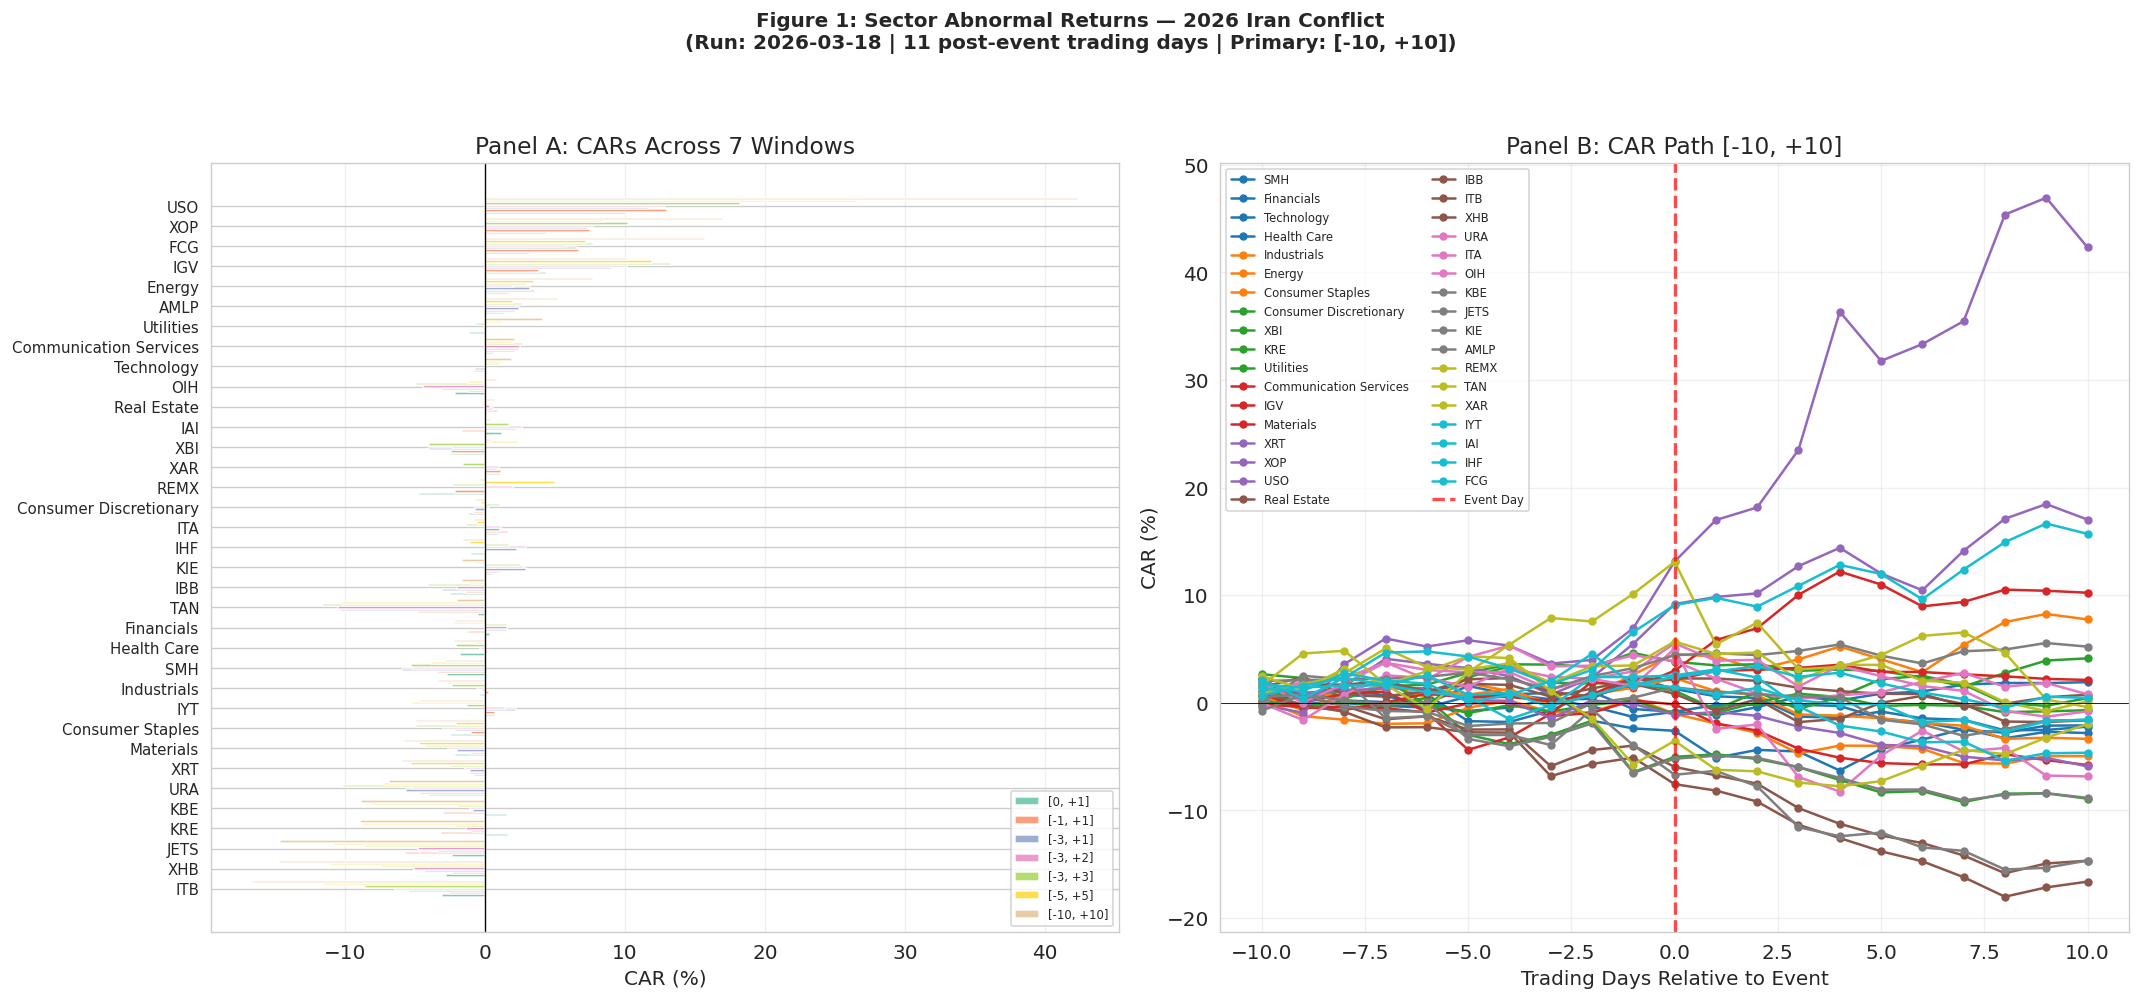

In [16]:
# ============================================================
# 4.2  Table 1 + Figure 1: Event Study Results (Dynamic)
#      Auto-adapts to however many windows were computed
# ============================================================
if all_window_results:
    # --- TABLE 1: Multi-window comparison ---
    print("=" * 80)
    print(f"TABLE 1: Cumulative Abnormal Returns — {len(windows)} windows")
    print(f"         Run date: {RUN_DATE.date()} | Post-event days: {n_post}")
    print("=" * 80)

    sectors_list = list(event_results.keys())
    sector_names = {s: SECTOR_ETFS.get(s, s) for s in sectors_list}

    rows = []
    for sec in sectors_list:
        row = {'Sector': sector_names[sec], 'Ticker': sec}
        if sec in event_results:
            row['Beta'] = round(event_results[sec]['beta'], 3)
        for wname in windows.keys():
            if sec in all_window_results[wname]:
                r = all_window_results[wname][sec]
                car_pct = r['CAR_total'] * 100
                sig = "***" if r['p_val'] < .01 else "**" if r['p_val'] < .05 else "*" if r['p_val'] < .1 else ""
                row[f'CAR {wname}'] = f"{car_pct:+.2f}{sig}"
            else:
                row[f'CAR {wname}'] = 'N/A'
        rows.append(row)

    tbl1 = pd.DataFrame(rows)
    primary_cars = {sec: event_results[sec]['CAR_total'] for sec in sectors_list if sec in event_results}
    tbl1['_sort'] = tbl1['Ticker'].map(primary_cars)
    tbl1 = tbl1.sort_values('_sort', ascending=False).drop(columns='_sort')
    print()
    display(tbl1.set_index('Sector'))
    print(f"\nPrimary window: {primary_window}")
    print("*** p<0.01, ** p<0.05, * p<0.10")


    # --- Φ SUMMARY ---
    phi_primary = phi_by_window.get(primary_window, np.nan)
    delta_primary = delta_by_window.get(primary_window, np.nan)
    if not np.isnan(phi_primary):
        print(f"\n{'─'*60}")
        print(f"Φ = {phi_primary:.3f}  (primary window: {primary_window})")
        print(f"  → {(1-phi_primary)*100:.1f}% of sector-level shock is hidden by the aggregate")
        print(f"  → Δ_missing = {delta_primary:+.2f} pp of portfolio value")
        print(f"{'─'*60}")

    # --- FIGURE 1 ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Panel A: Grouped bar chart (all windows)
    ax1 = axes[0]
    win_names = list(windows.keys())
    n_win = len(win_names)
    x = np.arange(len(sectors_list))
    width = 0.8 / n_win
    colors = plt.cm.Set2(np.linspace(0, 0.8, n_win))

    sorted_secs = sorted(sectors_list, key=lambda s: event_results.get(s, {}).get('CAR_total', 0))
    sorted_names = [sector_names[s] for s in sorted_secs]

    for i, wname in enumerate(win_names):
        cars = [all_window_results[wname].get(sec, {}).get('CAR_total', 0) * 100 for sec in sorted_secs]
        ax1.barh(x + i * width, cars, width, label=wname, color=colors[i], alpha=0.85)

    ax1.set_yticks(x + width * (n_win - 1) / 2)
    ax1.set_yticklabels(sorted_names, fontsize=9)
    ax1.axvline(0, color='black', lw=0.8)
    ax1.set_xlabel('CAR (%)')
    ax1.set_title(f'Panel A: CARs Across {n_win} Windows')
    ax1.legend(fontsize=7, loc='lower right')
    ax1.grid(True, axis='x', alpha=0.3)

    # Panel B: CAR path for widest window
    ax2 = axes[1]
    widest_win = list(windows.keys())[-1]  # last = widest
    wide_res = all_window_results[widest_win]
    cmap = plt.cm.tab10(np.linspace(0, 1, len(wide_res)))
    for (sec, r), c in zip(wide_res.items(), cmap):
        e = r['evt_data']
        ax2.plot(e['rel_day'], e['CAR'] * 100, label=sector_names.get(sec, sec),
                color=c, lw=1.5, marker='o', markersize=4)
    ax2.axvline(0, color='red', ls='--', lw=2, alpha=0.7, label='Event Day')
    ax2.axhline(0, color='black', lw=0.5)
    ax2.set_xlabel('Trading Days Relative to Event')
    ax2.set_ylabel('CAR (%)')
    ax2.set_title(f'Panel B: CAR Path {widest_win}')
    ax2.legend(fontsize=7, loc='best', ncol=2)
    ax2.grid(True, alpha=0.3)

    plt.suptitle(f'Figure 1: Sector Abnormal Returns — 2026 Iran Conflict\n'
                 f'(Run: {RUN_DATE.date()} | {n_post} post-event trading days | Primary: {primary_window})',
                 fontsize=12, fontweight='bold', y=1.04)
    plt.tight_layout()
    plt.savefig('figure1_event_study.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("[WARN] No event study results")

Cross-sectional regression: N = 34 ETFs
Window: [-10, +10]

TABLE 2: Cross-Sectional Determinants of CARs ([-10, +10])
                         (1) Univariate     (2) With β_mkt
────────────────────────────────────────────────────────────
const                    -2.558**            +0.217   
                           (-2.57)              (0.08)
beta_oil                +24.896***          +24.282***
                            (3.95)              (3.89)
beta_mkt                                     -3.058   
                                               (-0.95)
────────────────────────────────────────────────────────────
R²                           0.477               0.493
N                               34                  34
SEs                            HC3                 HC3
*** p<0.01, ** p<0.05, * p<0.10



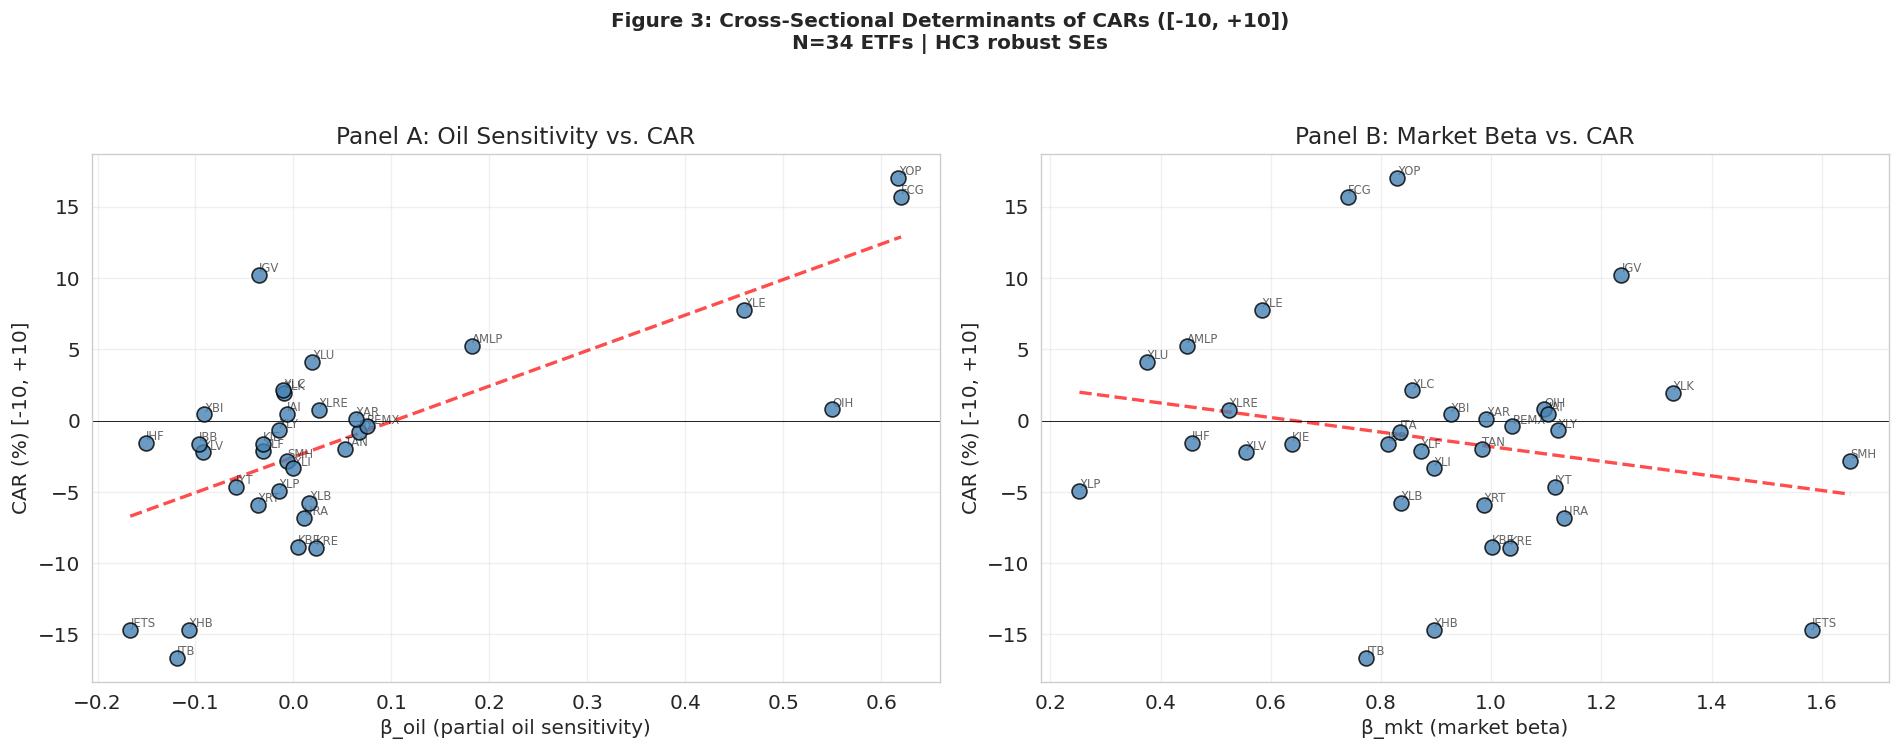

In [17]:
# ============================================================
# 4.3  Cross-Sectional Regression: CAR ~ β_oil + β_mkt
#      (Fix #8: HC3 robust SEs, Fix #9: β_mkt control)
#      Universe: ALL sub-sector ETFs that passed liquidity filter
# ============================================================
if event_results and len(beta_df) > 0:
    # Merge CARs with betas
    xs_data = beta_df[['name', 'beta_mkt', 'beta_oil', 't_oil']].copy()
    xs_data['CAR'] = xs_data.index.map(
        lambda t: event_results[t]['CAR_total'] * 100
        if t in event_results else np.nan
    )
    xs_data = xs_data.dropna(subset=['CAR', 'beta_oil'])

    # Drop SPY (it's the market, not a cross-section unit)
    xs_data = xs_data[xs_data.index != 'SPY']

    print(f"Cross-sectional regression: N = {len(xs_data)} ETFs")
    print(f"Window: {primary_window}\n")

    # --- Specification 1: Univariate (CAR ~ β_oil) ---
    X1 = sm.add_constant(xs_data['beta_oil'])
    ols1 = sm.OLS(xs_data['CAR'], X1).fit(cov_type='HC3')

    # --- Specification 2: With β_mkt control (Fix #9) ---
    X2 = sm.add_constant(xs_data[['beta_oil', 'beta_mkt']])
    ols2 = sm.OLS(xs_data['CAR'], X2).fit(cov_type='HC3')

    print("=" * 70)
    print(f"TABLE 2: Cross-Sectional Determinants of CARs ({primary_window})")
    print("=" * 70)
    print(f"{'':20s} {'(1) Univariate':>18s} {'(2) With β_mkt':>18s}")
    print(f"{'─'*60}")
    for var in ['const', 'beta_oil', 'beta_mkt']:
        if var in ols1.params.index:
            c1 = f"{ols1.params[var]:+.3f}"
            t1 = f"({ols1.tvalues[var]:.2f})"
            s1 = "***" if ols1.pvalues[var]<.01 else "**" if ols1.pvalues[var]<.05 else "*" if ols1.pvalues[var]<.1 else ""
        else:
            c1, t1, s1 = "", "", ""
        if var in ols2.params.index:
            c2 = f"{ols2.params[var]:+.3f}"
            t2 = f"({ols2.tvalues[var]:.2f})"
            s2 = "***" if ols2.pvalues[var]<.01 else "**" if ols2.pvalues[var]<.05 else "*" if ols2.pvalues[var]<.1 else ""
        else:
            c2, t2, s2 = "", "", ""
        print(f"{var:20s} {c1:>10s}{s1:3s}       {c2:>10s}{s2:3s}")
        print(f"{'':20s} {t1:>13s}       {t2:>13s}")
    print(f"{'─'*60}")
    print(f"{'R²':20s} {ols1.rsquared:>13.3f}       {ols2.rsquared:>13.3f}")
    print(f"{'N':20s} {int(ols1.nobs):>13d}       {int(ols2.nobs):>13d}")
    print(f"{'SEs':20s} {'HC3':>13s}       {'HC3':>13s}")
    print("*** p<0.01, ** p<0.05, * p<0.10\n")

    # --- FIGURE: Scatter plot ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    for ax, xvar, xlabel, model in [
        (ax1, 'beta_oil', 'β_oil (partial oil sensitivity)', ols1),
        (ax2, 'beta_mkt', 'β_mkt (market beta)', ols2),
    ]:
        ax.scatter(xs_data[xvar], xs_data['CAR'], s=80, c='steelblue',
                   edgecolor='black', zorder=5, alpha=0.8)
        for t, row in xs_data.iterrows():
            ax.annotate(t, (row[xvar], row['CAR']), fontsize=7,
                        ha='left', va='bottom', alpha=0.7)
        # Fitted line
        z = np.polyfit(xs_data[xvar], xs_data['CAR'], 1)
        xl = np.linspace(xs_data[xvar].min(), xs_data[xvar].max(), 100)
        ax.plot(xl, np.poly1d(z)(xl), 'r--', alpha=0.7, lw=2)
        ax.axhline(0, color='black', lw=0.5)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(f'CAR (%) {primary_window}')
        ax.grid(True, alpha=0.3)

    ax1.set_title('Panel A: Oil Sensitivity vs. CAR')
    ax2.set_title('Panel B: Market Beta vs. CAR')
    plt.suptitle(f'Figure 3: Cross-Sectional Determinants of CARs ({primary_window})\n'
                 f'N={len(xs_data)} ETFs | HC3 robust SEs',
                 fontsize=12, fontweight='bold', y=1.04)
    plt.tight_layout()
    plt.savefig('figure3_cross_section.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Store for summary
    gamma1_hat = ols2.params.get('beta_oil', np.nan)
    gamma1_t   = ols2.tvalues.get('beta_oil', np.nan)
    gamma1_p   = ols2.pvalues.get('beta_oil', np.nan)
    xs_r2      = ols2.rsquared
    xs_n       = int(ols2.nobs)
else:
    print("[INFO] Need event study + beta estimation first")
    gamma1_hat = gamma1_t = gamma1_p = xs_r2 = xs_n = np.nan

Running double bootstrap (2000 iterations) ...
  Each iteration: resample estimation window → re-estimate betas → re-estimate CARs → cross-section

Completed: 2000/2000 valid iterations

DOUBLE BOOTSTRAP INFERENCE FOR γ₁ (oil sensitivity → CAR)
Point estimate (OLS):    γ₁ = +24.2821
Bootstrap mean:          γ₁* = +23.1834
Bootstrap SE:            4.1884
95% CI (percentile):     [+15.2502, +31.5567]
Bootstrap p-value:       0.3930
  (share of |γ₁*| ≥ |γ₁_obs| under resampling)


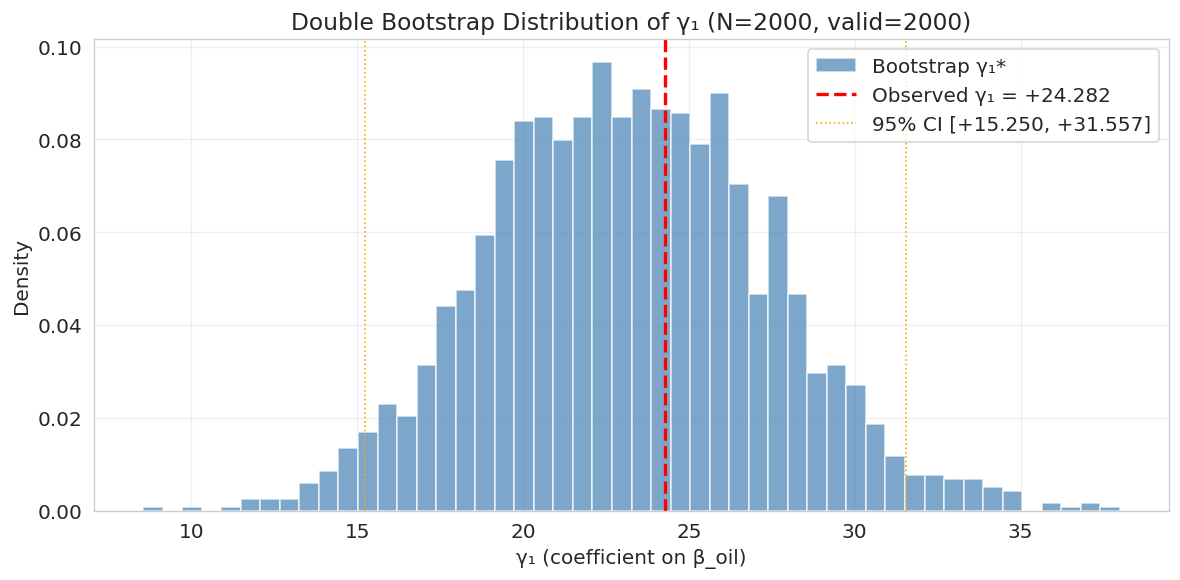

In [18]:
# ============================================================
# 4.4  Double Bootstrap Inference for γ₁  (Fix #7, Trap 1)
#      Hand-rolled with numpy (no arch dependency).
#      Uses np.linalg.lstsq inside loop — ~30s for 2000 reps.
# ============================================================
N_BOOT = 2000  # Sufficient for SEs; 10K would freeze (Trap 1)

if event_results and len(beta_df) > 0 and not np.isnan(gamma1_hat):
    print(f"Running double bootstrap ({N_BOOT} iterations) ...")
    print("  Each iteration: resample estimation window → re-estimate betas → re-estimate CARs → cross-section")

    rng = np.random.default_rng(42)

    # Pre-extract numpy arrays for speed (Trap 1: avoid pandas/statsmodels in loop)
    tickers_xs = xs_data.index.tolist()
    mkt_col = filtered_returns.columns.get_loc('SPY')
    uso_col = filtered_returns.columns.get_loc('USO') if 'USO' in filtered_returns.columns else None
    est_returns_np = filtered_returns.reindex(est_dates).values  # (T_est, N_etfs)
    col_map = {t: filtered_returns.columns.get_loc(t) for t in tickers_xs
               if t in filtered_returns.columns}

    # Event window returns (fixed — we only resample estimation window)
    prim_win = windows[primary_window]
    evt_s_idx = max(0, evt_idx + prim_win[0])
    evt_e_idx = min(len(trading_days_all) - 1, evt_idx + prim_win[1])
    evt_dates_boot = trading_days_all[evt_s_idx:evt_e_idx + 1]
    evt_returns_np = filtered_returns.reindex(evt_dates_boot).values

    T_est = est_returns_np.shape[0]
    gamma1_boot = np.full(N_BOOT, np.nan)

    for b in range(N_BOOT):
        # Step 1: Resample estimation window rows with replacement
        idx_b = rng.integers(0, T_est, size=T_est)
        est_b = est_returns_np[idx_b]

        mkt_b = est_b[:, mkt_col]
        uso_b = est_b[:, uso_col] if uso_col is not None else None

        betas_oil_b = np.full(len(tickers_xs), np.nan)
        betas_mkt_b = np.full(len(tickers_xs), np.nan)
        cars_b      = np.full(len(tickers_xs), np.nan)

        for i, t in enumerate(tickers_xs):
            if t not in col_map:
                continue
            ci = col_map[t]
            y_est = est_b[:, ci]
            valid = np.isfinite(y_est) & np.isfinite(mkt_b)
            if uso_b is not None:
                valid_2f = valid & np.isfinite(uso_b)
            else:
                valid_2f = valid

            if valid.sum() < 30:
                continue

            # Single-factor model for CARs (matches run_event_study)
            X_1f = np.column_stack([np.ones(valid.sum()), mkt_b[valid]])
            c_1f, _, _, _ = np.linalg.lstsq(X_1f, y_est[valid], rcond=None)
            alpha_1f, beta_mkt_1f = c_1f[0], c_1f[1]

            # Two-factor model for β_oil (cross-section regressor only)
            if uso_b is not None and valid_2f.sum() >= 30:
                X_2f = np.column_stack([np.ones(valid_2f.sum()), mkt_b[valid_2f], uso_b[valid_2f]])
                c_2f, _, _, _ = np.linalg.lstsq(X_2f, y_est[valid_2f], rcond=None)
                betas_mkt_b[i] = c_2f[1]
                betas_oil_b[i] = c_2f[2]
            else:
                betas_mkt_b[i] = beta_mkt_1f
                betas_oil_b[i] = np.nan

            # Step 2: CARs from single-factor model (consistent pipeline)
            evt_sec = evt_returns_np[:, ci]
            evt_mkt_v = evt_returns_np[:, mkt_col]
            evt_valid = np.isfinite(evt_sec) & np.isfinite(evt_mkt_v)
            if evt_valid.sum() == 0:
                continue
            expected = alpha_1f + beta_mkt_1f * evt_mkt_v[evt_valid]
            ar_b = evt_sec[evt_valid] - expected
            cars_b[i] = np.sum(ar_b) * 100  # in %

        # Step 3: Cross-sectional regression
        valid_xs = np.isfinite(cars_b) & np.isfinite(betas_oil_b) & np.isfinite(betas_mkt_b)
        if valid_xs.sum() < 10:
            continue
        y_xs = cars_b[valid_xs]
        X_xs = np.column_stack([
            np.ones(valid_xs.sum()),
            betas_oil_b[valid_xs],
            betas_mkt_b[valid_xs],
        ])
        g_b, _, _, _ = np.linalg.lstsq(X_xs, y_xs, rcond=None)
        gamma1_boot[b] = g_b[1]  # coefficient on beta_oil

    # Results
    valid_boots = gamma1_boot[np.isfinite(gamma1_boot)]
    print(f"\nCompleted: {len(valid_boots)}/{N_BOOT} valid iterations")

    boot_mean = np.mean(valid_boots)
    boot_se   = np.std(valid_boots)
    boot_ci_lo = np.percentile(valid_boots, 2.5)
    boot_ci_hi = np.percentile(valid_boots, 97.5)
    boot_p = np.mean(np.abs(valid_boots) >= abs(gamma1_hat))

    print(f"\n{'='*60}")
    print(f"DOUBLE BOOTSTRAP INFERENCE FOR γ₁ (oil sensitivity → CAR)")
    print(f"{'='*60}")
    print(f"Point estimate (OLS):    γ₁ = {gamma1_hat:+.4f}")
    print(f"Bootstrap mean:          γ₁* = {boot_mean:+.4f}")
    print(f"Bootstrap SE:            {boot_se:.4f}")
    print(f"95% CI (percentile):     [{boot_ci_lo:+.4f}, {boot_ci_hi:+.4f}]")
    print(f"Bootstrap p-value:       {boot_p:.4f}")
    print(f"  (share of |γ₁*| ≥ |γ₁_obs| under resampling)")

    # Figure: Bootstrap distribution
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(valid_boots, bins=50, density=True, alpha=0.7, color='steelblue',
            edgecolor='white', label='Bootstrap γ₁*')
    ax.axvline(gamma1_hat, color='red', lw=2, ls='--',
               label=f'Observed γ₁ = {gamma1_hat:+.3f}')
    ax.axvline(boot_ci_lo, color='orange', lw=1, ls=':',
               label=f'95% CI [{boot_ci_lo:+.3f}, {boot_ci_hi:+.3f}]')
    ax.axvline(boot_ci_hi, color='orange', lw=1, ls=':')
    ax.set_xlabel('γ₁ (coefficient on β_oil)')
    ax.set_ylabel('Density')
    ax.set_title(f'Double Bootstrap Distribution of γ₁ (N={N_BOOT}, valid={len(valid_boots)})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('figure_bootstrap.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("[INFO] Need cross-sectional regression results first")
    boot_ci_lo = boot_ci_hi = boot_p = np.nan

Running placebo event studies ...
  Placebo window: 2020-06-01 to 2025-12-31
  Minimum gap: 15 trading days (Fix #12)
  USO restricted to post-Jun 2020 (Trap 3: structural break)
  Available trading days: 1405
  Non-overlapping placebos drawn: 72
  Valid placebo Φ values: 0

PLACEBO TEST RESULTS
Actual Φ (Hormuz, [-10, +10]): nan
Placebo Φ: mean=nan, median=nan, std=nan
Percentile rank of actual Φ: nan%
  (lower Φ = more masking → lower percentile is MORE extreme)

Historical events:


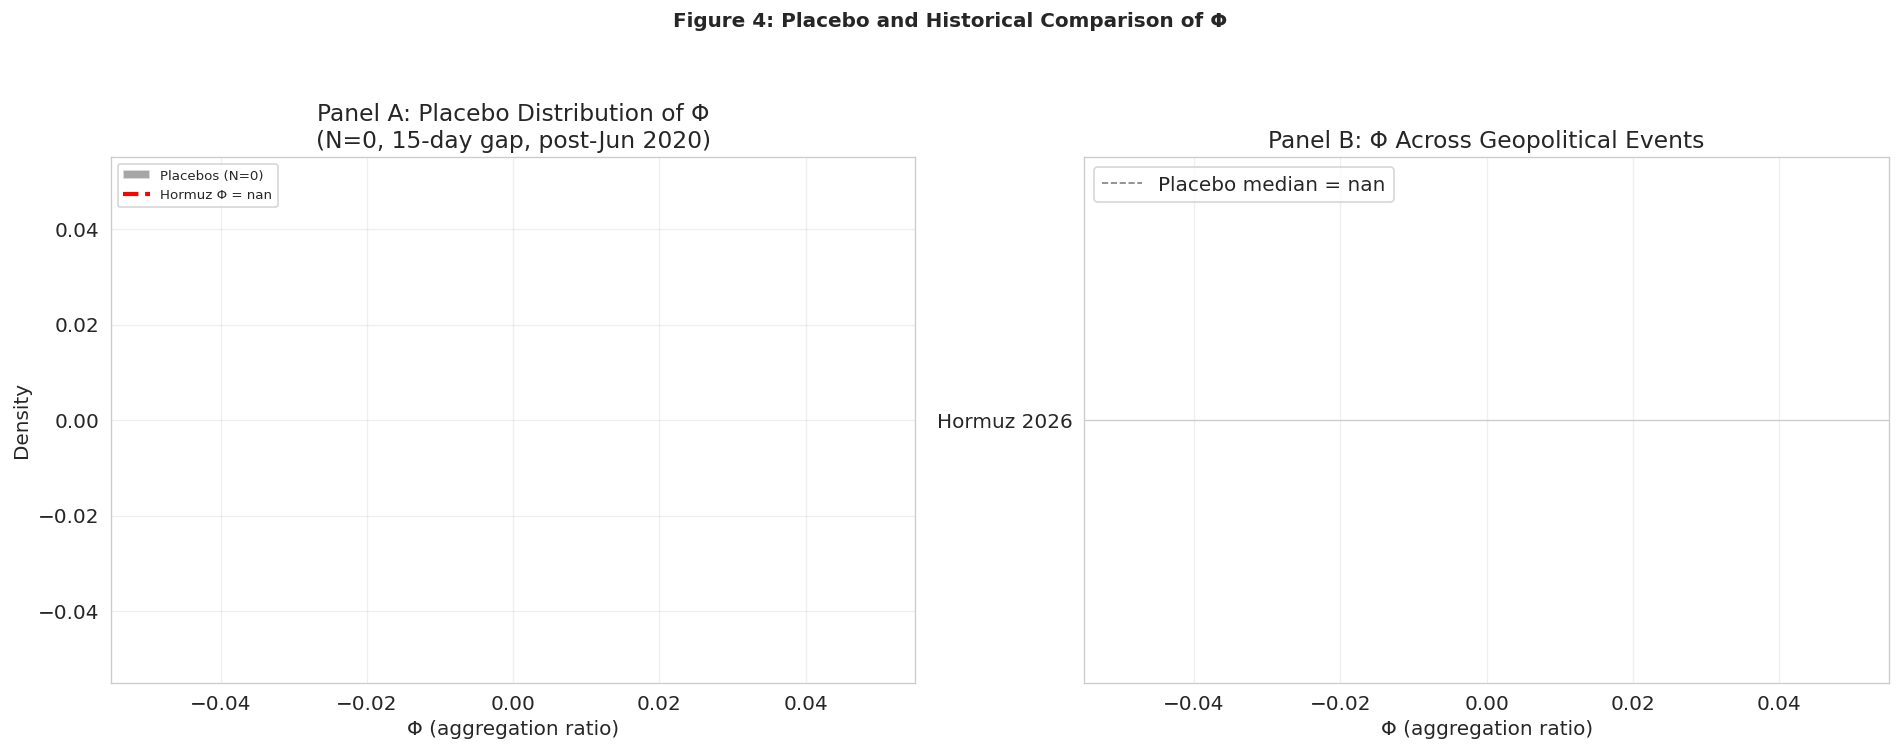

In [19]:
# ============================================================
# 4.5  Placebo Tests  (Fix #12, Trap 3)
#      A: Random pseudo-events with 15-day min gap, post-Jun 2020
#      B: Historical geopolitical events
# ============================================================

# --- PART A: Random placebos ---
print("Running placebo event studies ...")
print(f"  Placebo window: {PLACEBO_START} to {PLACEBO_END}")
print(f"  Minimum gap: {PLACEBO_MIN_GAP} trading days (Fix #12)")
print(f"  USO restricted to post-Jun 2020 (Trap 3: structural break)")

# Get trading days in placebo range
placebo_trading_days = filtered_returns.index[
    (filtered_returns.index >= PLACEBO_START) &
    (filtered_returns.index <= PLACEBO_END)
].sort_values()
print(f"  Available trading days: {len(placebo_trading_days)}")

# Draw non-overlapping random dates (Fix #12: enforce 15-day gap)
rng_p = np.random.default_rng(123)
available = list(range(len(placebo_trading_days)))
placebo_dates = []
max_attempts = 5000
attempts = 0

while available and attempts < max_attempts:
    pick = rng_p.choice(available)
    pick_date_idx = pick
    # Check gap with all previously selected
    conflict = False
    for prev in placebo_dates:
        if abs(pick - prev) < PLACEBO_MIN_GAP:
            conflict = True
            break
    if not conflict:
        placebo_dates.append(pick)
        # Remove nearby indices from available pool
        available = [a for a in available if abs(a - pick) >= PLACEBO_MIN_GAP]
    attempts += 1

placebo_dates.sort()
placebo_event_dates = [placebo_trading_days[i] for i in placebo_dates]
print(f"  Non-overlapping placebos drawn: {len(placebo_event_dates)}")

# Run event study for each placebo (use primary window spec)
prim_pre, prim_post = windows[primary_window]
phi_placebo = []

# Use GICS-only returns for Φ (same as real event)
gics_tickers = ['SPY'] + list(GICS_WEIGHTS.keys())
gics_returns = filtered_returns[[c for c in gics_tickers if c in filtered_returns.columns]]

for i, pdate in enumerate(placebo_event_dates):
    res_p, _, _, _ = run_event_study(
        gics_returns, market='SPY', event_date=pdate, evt_win=(prim_pre, prim_post)
    )
    if 'SPY' in res_p and len(res_p) >= 8:
        spy_car_p = res_p['SPY']['CAR_total']
        sector_res_p = {k: v for k, v in res_p.items() if k != 'SPY'}
        phi_p, _ = compute_phi(sector_res_p, spy_car_p)
        if not np.isnan(phi_p):
            phi_placebo.append(phi_p)

print(f"  Valid placebo Φ values: {len(phi_placebo)}")

# --- PART B: Historical events ---
HISTORICAL_EVENTS = {
    '2020-03-09': 'COVID Crash',
    '2022-02-24': 'Russia-Ukraine',
    '2022-10-05': 'OPEC+ Cut',
    '2023-10-09': 'Hamas Attack',
}
phi_historical = {}
for date_str, label in HISTORICAL_EVENTS.items():
    hdate = pd.Timestamp(date_str)
    # Only run if we have data around this date
    if hdate < gics_returns.index.min() or hdate > gics_returns.index.max():
        continue
    res_h, _, _, _ = run_event_study(
        gics_returns, market='SPY', event_date=hdate, evt_win=(prim_pre, prim_post)
    )
    if 'SPY' in res_h and len(res_h) >= 8:
        spy_car_h = res_h['SPY']['CAR_total']
        sector_res_h = {k: v for k, v in res_h.items() if k != 'SPY'}
        phi_h, _ = compute_phi(sector_res_h, spy_car_h)
        phi_historical[label] = phi_h

# --- Results ---
phi_actual = phi_by_window.get(primary_window, np.nan)
phi_placebo_arr = np.array(phi_placebo)

print(f"\n{'='*60}")
print(f"PLACEBO TEST RESULTS")
print(f"{'='*60}")
print(f"Actual Φ (Hormuz, {primary_window}): {phi_actual:.3f}")
print(f"Placebo Φ: mean={phi_placebo_arr.mean():.3f}, "
      f"median={np.median(phi_placebo_arr):.3f}, "
      f"std={phi_placebo_arr.std():.3f}")
pct_rank = np.mean(phi_placebo_arr <= phi_actual) * 100
print(f"Percentile rank of actual Φ: {pct_rank:.1f}%")
print(f"  (lower Φ = more masking → lower percentile is MORE extreme)")

print(f"\nHistorical events:")
for label, phi_h in phi_historical.items():
    print(f"  {label:25s}  Φ = {phi_h:.3f}")

# Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Placebo distribution
ax1.hist(phi_placebo_arr, bins=25, density=True, alpha=0.7, color='gray',
         edgecolor='white', label=f'Placebos (N={len(phi_placebo)})')
ax1.axvline(phi_actual, color='red', lw=2.5, ls='--',
            label=f'Hormuz Φ = {phi_actual:.3f}')
for label, phi_h in phi_historical.items():
    ax1.axvline(phi_h, lw=1.5, ls=':', alpha=0.7,
                label=f'{label} Φ = {phi_h:.3f}')
ax1.set_xlabel('Φ (aggregation ratio)')
ax1.set_ylabel('Density')
ax1.set_title(f'Panel A: Placebo Distribution of Φ\n'
              f'(N={len(phi_placebo)}, {PLACEBO_MIN_GAP}-day gap, post-Jun 2020)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Panel B: Historical comparison
events = {'Hormuz 2026': phi_actual}
events.update(phi_historical)
colors = ['red'] + ['steelblue'] * len(phi_historical)
ax2.barh(list(events.keys()), list(events.values()), color=colors, edgecolor='black')
ax2.axvline(np.median(phi_placebo_arr), color='gray', ls='--', lw=1,
            label=f'Placebo median = {np.median(phi_placebo_arr):.3f}')
ax2.set_xlabel('Φ (aggregation ratio)')
ax2.set_title('Panel B: Φ Across Geopolitical Events')
ax2.legend()
ax2.grid(True, axis='x', alpha=0.3)

plt.suptitle(f'Figure 4: Placebo and Historical Comparison of Φ',
             fontsize=12, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('figure4_placebo.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Section 5: VAR Analysis, IRFs, and Granger Causality

The VAR automatically uses all available monthly data. As post-event macro releases arrive (BLS employment, CPI, industrial production), the model incorporates them on re-run.

- **Early runs (< 1 month post-event):** VAR on pre-event data + counterfactual forecast
- **Later runs (1+ months post-event):** VAR includes post-event data → tests actual transmission

In [20]:
# ============================================================
# 5.1  Build VAR Dataset (monthly, stationary)
#      ROBUST: Auto-detects whether post-event monthly data
#      exists. Uses ALL available data.
# ============================================================
def adf_test(s, name):
    c = s.dropna()
    if len(c) < 10: return name, np.nan, np.nan, 'Too short'
    r = adfuller(c, autolag='AIC')
    status = 'Stationary' if r[1] < .05 else 'Non-stationary'
    return name, r[0], r[1], status

var_cands = {}
if len(epu_monthly_chg) > 0:
    var_cands['EPU'] = epu_monthly_chg
if 'WTI_monthly_ret' in monthly_macro.columns:
    var_cands['Oil_Ret'] = monthly_macro['WTI_monthly_ret']
if 'INDPRO' in monthly_macro.columns:
    var_cands['IndProd_g'] = monthly_macro['INDPRO'].pct_change() * 100
if 'UNRATE' in monthly_macro.columns:
    var_cands['Unemp_chg'] = monthly_macro['UNRATE'].diff()
if 'CPIAUCSL' in monthly_macro.columns:
    var_cands['CPI_inf'] = monthly_macro['CPIAUCSL'].pct_change() * 100

var_df = pd.DataFrame(var_cands).dropna()
n_obs, n_vars = var_df.shape

# Auto-detect pre vs post event coverage
last_var_date = var_df.index.max()
post_event_months = len(var_df[var_df.index >= EVENT_DATE])
has_post_event = post_event_months > 0

print(f"VAR dataset: {n_obs} months × {n_vars} vars")
print(f"Date range:  {var_df.index.min().date()} to {last_var_date.date()}")
print(f"Post-event months in VAR: {post_event_months}")
if has_post_event:
    print(f">>> VAR INCLUDES post-event data — transmission analysis is direct")
else:
    print(f">>> VAR is PRE-EVENT only — will generate counterfactual forecast")
    print(f"    (Monthly macro data not yet released for post-event period)")

print("\n--- ADF Stationarity Tests ---")
print(f"{'Variable':<15s} {'ADF':>8s} {'p-val':>8s} {'Status'}")
for col in var_df.columns:
    n, a, p, st = adf_test(var_df[col], col)
    print(f"{n:<15s} {a:8.3f} {p:8.4f} {st}")

# statsmodels exact maxlags formula
safe_maxlags = (n_obs - n_vars - 1) // (1 + n_vars)
safe_maxlags = max(1, safe_maxlags)
print(f"\nSafe maxlags: {safe_maxlags}")
print(f"  formula: ({n_obs} - {n_vars} - 1) // (1 + {n_vars}) = {safe_maxlags}")


# ── COVID dummy (Fix #10) ──
covid_dummy = pd.Series(0, index=var_df.index, name='COVID')
covid_dummy[(var_df.index >= COVID_START) & (var_df.index <= COVID_END)] = 1
n_covid = covid_dummy.sum()
if n_covid > 0:
    print(f"\nCOVID dummy: {int(n_covid)} months flagged ({COVID_START.date()} to {COVID_END.date()})")
else:
    print("\nCOVID dummy: no COVID months in sample")

display(var_df.tail())

VAR dataset: 35 months × 5 vars
Date range:  2023-02-01 to 2026-02-01
Post-event months in VAR: 0
>>> VAR is PRE-EVENT only — will generate counterfactual forecast
    (Monthly macro data not yet released for post-event period)

--- ADF Stationarity Tests ---
Variable             ADF    p-val Status
EPU               -6.664   0.0000 Stationary
Oil_Ret           -5.791   0.0000 Stationary
IndProd_g         -7.555   0.0000 Stationary
Unemp_chg         -8.989   0.0000 Stationary
CPI_inf           -4.867   0.0000 Stationary

Safe maxlags: 4
  formula: (35 - 5 - 1) // (1 + 5) = 4

COVID dummy: no COVID months in sample


,EPU,Oil_Ret,IndProd_g,Unemp_chg,CPI_inf
date,,,,,
2025-08-01,-17.484655,-5.156567,-0.264294,0.0,0.348264
2025-09-01,11.395585,-1.395588,0.042608,0.1,0.295090
2025-12-01,4.775587,-3.479641,0.313337,-0.1,0.297788
2026-01-01,-0.615523,3.561577,0.706347,-0.1,0.170843
2026-02-01,3.044747,7.447776,0.151080,0.1,0.267003


 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      0.4053     0.6366*       1.500      0.4807
1      0.3998       1.788       1.529      0.8522
2      0.5416       3.086       2.020       1.371
3     -0.7830       2.918      0.7915      0.4233
4     -3.142*       1.715     0.1876*     -1.559*
-------------------------------------------------

Optimal lag (AIC): 4
VAR(4) estimated: 31 obs
Sample: 2023-06-01 to 2026-02-01
>>> Pre-event only (through 2026-02-01)


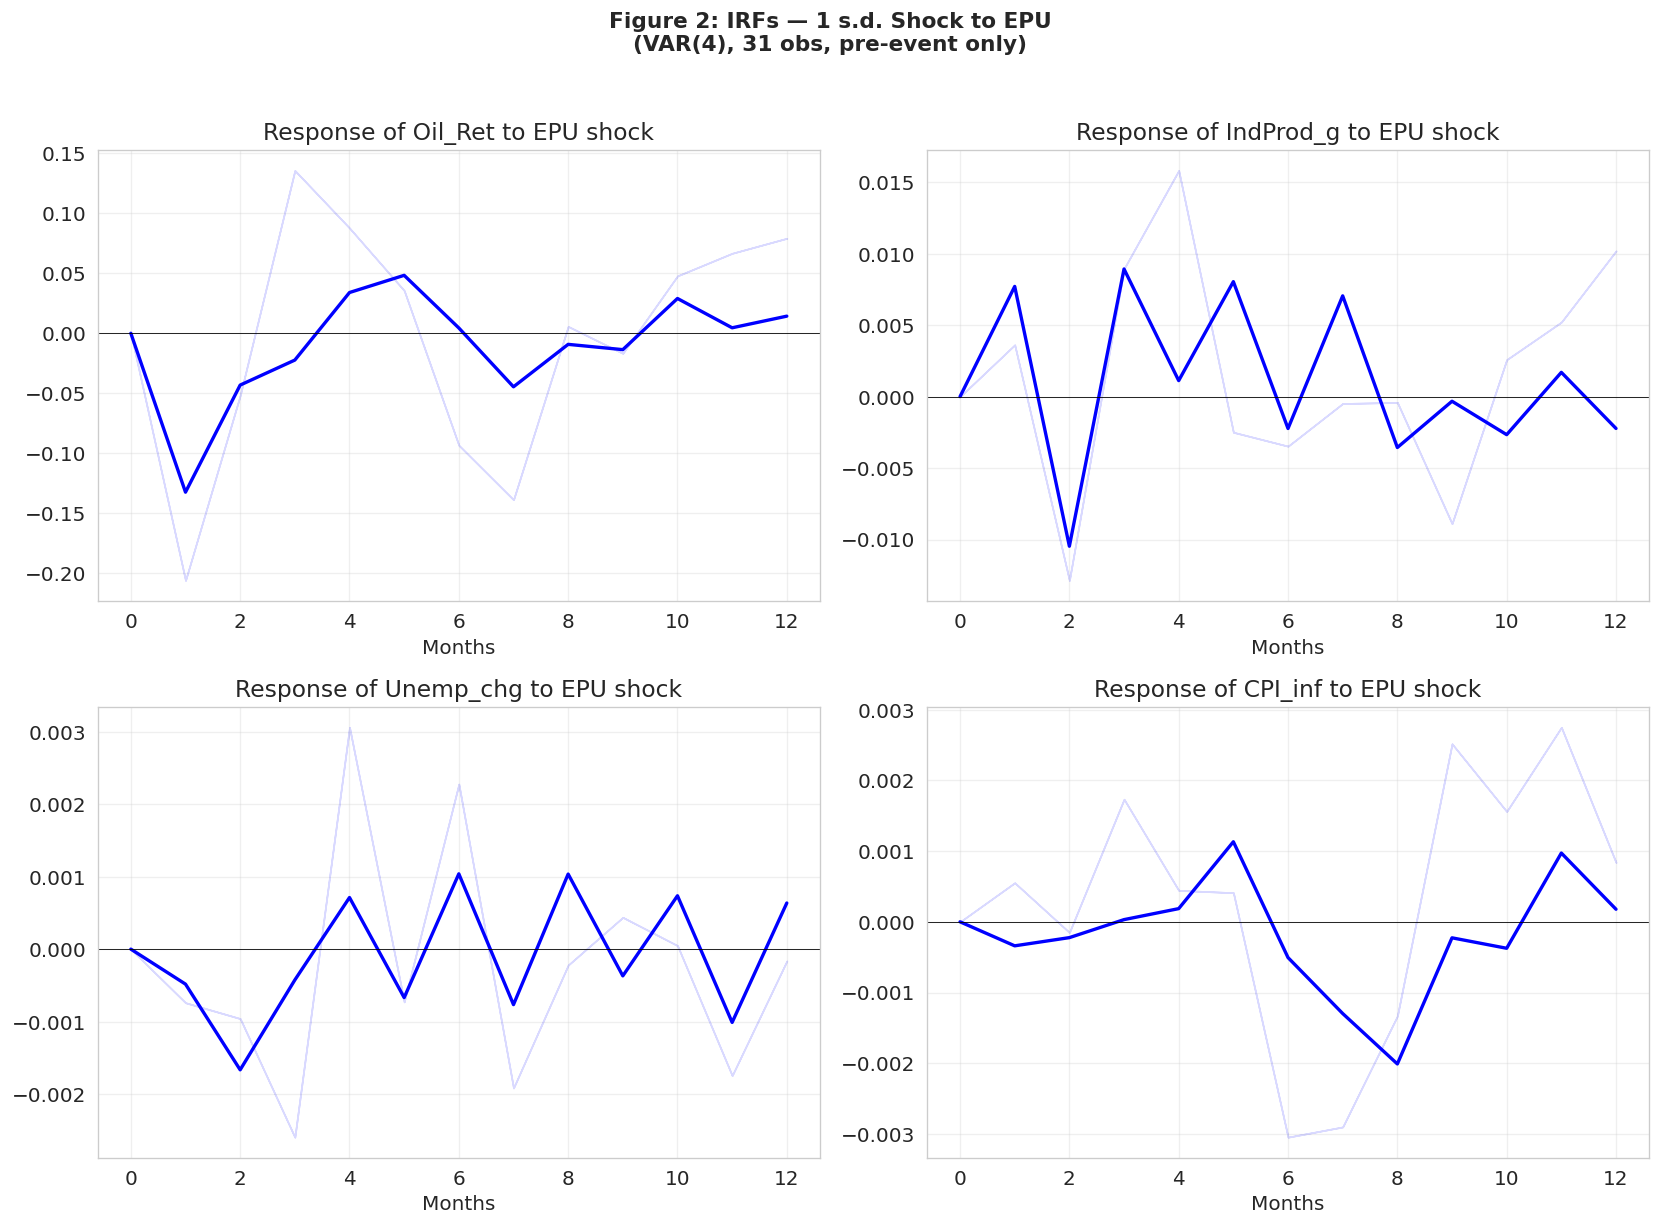


COUNTERFACTUAL FORECAST: EPU shock ≈ 18.5% (0.6 s.d.)
EPU monthly change std (sample):  29.7%
Shock magnitude (2026-03-01):   +18.5% = 0.6 s.d.

IRF-implied effects of a 0.6 s.d. EPU shock:
  Oil_Ret     : 1-mo: -0.083 % oil return  |  3-mo cum: -0.109  |  6-mo cum: -0.072
  IndProd_g   : 1-mo: +0.005 % IP growth  |  3-mo cum: -0.002  |  6-mo cum: +0.010
  Unemp_chg   : 1-mo: -0.000 pp unemployment  |  3-mo cum: -0.001  |  6-mo cum: -0.002
  CPI_inf     : 1-mo: -0.000 % CPI inflation  |  3-mo cum: -0.000  |  6-mo cum: +0.000

[Pre-event only — forecasts to be validated as macro data arrives]


In [21]:
# ============================================================
# 5.2  Estimate VAR + IRFs + Conditional Forecast (Figure 2)
#      ROBUST: If pre-event only → counterfactual forecast
#              If post-event data exists → actual vs predicted
# ============================================================
if var_df.shape[0] >= 20 and var_df.shape[1] >= 3:
    var_exog = covid_dummy.values.reshape(-1, 1) if n_covid > 0 else None
    var_sel = VAR(var_df, exog=var_exog)
    lag_res = var_sel.select_order(maxlags=safe_maxlags)
    # Note: select_order does not accept exog; exog is handled in fit()
    print(lag_res.summary())
    opt_lag = max(1, lag_res.aic)
    print(f"\nOptimal lag (AIC): {opt_lag}")

    var_model = var_sel.fit(opt_lag)
    print(f"VAR({opt_lag}) estimated: {var_model.nobs} obs")
    print(f"Sample: {var_df.index[opt_lag].date()} to {var_df.index[-1].date()}")
    if has_post_event:
        print(f">>> Includes {post_event_months} post-event month(s)")
    else:
        print(f">>> Pre-event only (through {var_df.index[-1].date()})")

    # --- IRFs ---
    irf = var_model.irf(periods=12)
    var_names = list(var_model.names)
    shock_var = 'EPU' if 'EPU' in var_names else var_names[0]
    shock_idx = var_names.index(shock_var)
    resp_vars = [v for v in var_names if v != shock_var]

    ncols = min(2, len(resp_vars))
    nrows = (len(resp_vars) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
    axes_flat = np.array(axes).flatten() if len(resp_vars) > 1 else [axes]

    # Compute Monte Carlo confidence intervals
    # statsmodels ≥0.14: method renamed to errband_mc (no underscore)
    irf_ci = irf.errband_mc(repl=1000, signif=0.05, seed=42)
    lower_band = irf_ci[0]  # lower 95% CI
    upper_band = irf_ci[1]  # upper 95% CI

    for i, rv in enumerate(resp_vars):
        ri = var_names.index(rv)
        vals = irf.irfs[:, ri, shock_idx]
        lo = lower_band[:, ri, shock_idx]
        hi = upper_band[:, ri, shock_idx]
        ax = axes_flat[i]
        ax.plot(range(len(vals)), vals, 'b-', lw=2)
        ax.fill_between(range(len(vals)), lo, hi,
                        alpha=.15, color='blue')
        ax.axhline(0, color='black', lw=.5)
        ax.set_title(f'Response of {rv} to {shock_var} shock')
        ax.set_xlabel('Months')
        ax.grid(True, alpha=.3)

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    status = f"incl. {post_event_months} post-event mo." if has_post_event else "pre-event only"
    plt.suptitle(f'Figure 2: IRFs — 1 s.d. Shock to {shock_var}\n'
                 f'(VAR({opt_lag}), {var_model.nobs} obs, {status})',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('figure2_irf.png', dpi=300, bbox_inches='tight')
    plt.show()

    # --- COUNTERFACTUAL / ACTUAL COMPARISON ---
    epu_std = var_df['EPU'].std()

    # Compute the actual EPU shock magnitude
    # Use the last pre-event EPU value vs first post-event
    pre_epu = epu_monthly_chg[epu_monthly_chg.index < EVENT_DATE]
    post_epu_vals = epu_monthly_chg[epu_monthly_chg.index >= EVENT_DATE]

    if len(post_epu_vals) > 0:
        epu_shock = post_epu_vals.iloc[0]
        shock_date = post_epu_vals.index[0].date()
    else:
        # Estimate from daily data: avg EPU in Feb post-event vs Jan
        epu_daily = fred_daily_df['USEPUINDXD'] if 'USEPUINDXD' in fred_daily_df.columns else None
        if epu_daily is not None:
            jan_avg = epu_daily['2026-01'].mean()
            feb_post = epu_daily[epu_daily.index >= EVENT_DATE].head(5).mean()
            epu_shock = ((feb_post - jan_avg) / jan_avg) * 100 if jan_avg > 0 else 30.0
            shock_date = EVENT_DATE.date()
        else:
            epu_shock = 30.0
            shock_date = EVENT_DATE.date()

    n_sd = epu_shock / epu_std if epu_std > 0 else 1.0

    print(f"\n{'=' * 60}")
    if has_post_event:
        print(f"POST-EVENT ANALYSIS: Actual EPU shock = {epu_shock:.1f}% ({n_sd:.1f} s.d.)")
    else:
        print(f"COUNTERFACTUAL FORECAST: EPU shock ≈ {epu_shock:.1f}% ({n_sd:.1f} s.d.)")
    print(f"{'=' * 60}")
    print(f"EPU monthly change std (sample):  {epu_std:.1f}%")
    print(f"Shock magnitude ({shock_date}):   {epu_shock:+.1f}% = {n_sd:.1f} s.d.")
    print(f"\nIRF-implied effects of a {n_sd:.1f} s.d. EPU shock:")

    units = {'Oil_Ret': '% oil return', 'IndProd_g': '% IP growth',
             'Unemp_chg': 'pp unemployment', 'CPI_inf': '% CPI inflation'}
    for rv in resp_vars:
        ri = var_names.index(rv)
        impact_1m = irf.irfs[1, ri, shock_idx] * n_sd
        cum_3m = sum(irf.irfs[:3, ri, shock_idx]) * n_sd
        cum_6m = sum(irf.irfs[:min(6, len(irf.irfs)), ri, shock_idx]) * n_sd
        u = units.get(rv, '')
        print(f"  {rv:12s}: 1-mo: {impact_1m:+.3f} {u}  |  3-mo cum: {cum_3m:+.3f}  |  6-mo cum: {cum_6m:+.3f}")

    if has_post_event:
        print(f"\n[Post-event data available — compare forecasts with actual releases]")
    else:
        print(f"\n[Pre-event only — forecasts to be validated as macro data arrives]")
else:
    var_model = None
    print(f"[WARN] Need ≥20 obs and ≥3 vars. Got {var_df.shape}")

In [22]:
# ============================================================
# 5.3  FEVD (Table 2) + Granger Causality (Table 3)
#      NOTE: These are estimated on PRE-EVENT data (through
#      Jan 2026). They characterize HISTORICAL transmission,
#      not the current crisis response.
# ============================================================

# --- Table 2: FEVD ---
if var_model is not None:
    fevd = var_model.fevd(12)
    var_names = list(var_model.names)
    shock_var = 'EPU' if 'EPU' in var_names else var_names[0]
    si = var_names.index(shock_var)
    print("=" * 70)
    print(f"TABLE 2: FEVD — % of forecast error variance explained by {shock_var}")
    print(f"         (Pre-event sample: {var_df.index[0].date()} to {var_df.index[-1].date()})")
    print("=" * 70)
    fevd_rows = []
    for vn in var_names:
        vi = var_names.index(vn)
        row = {'Variable': vn}
        for h in [1, 3, 6, 12]:
            if h <= fevd.decomp.shape[0]:
                row[f'h={h}'] = round(fevd.decomp[h-1, vi, si] * 100, 2)
        fevd_rows.append(row)
    display(pd.DataFrame(fevd_rows).set_index('Variable'))
    print("\nInterpretation: At h=1, EPU explains substantial variance in oil")
    print("and output through contemporaneous correlation (Cholesky ordering).")
    print("By h=3-6, own dynamics dominate → EPU effects are SHORT-LIVED.")

# --- Table 3: Granger Causality ---
if var_df.shape[0] >= 20 and var_df.shape[1] >= 2:
    shock_col = 'EPU' if 'EPU' in var_df.columns else var_df.columns[0]
    resp_cols = [c for c in var_df.columns if c != shock_col]
    max_gc = max(1, min(4, var_df.shape[0] // 8))
    print(f"\n{'=' * 70}")
    print(f"TABLE 3: Granger Causality — Does {shock_col} predict real variables?")
    print(f"         (Pre-event sample, maxlag={max_gc})")
    print(f"{'=' * 70}")
    gc_rows = []
    for rc in resp_cols:
        td = var_df[[rc, shock_col]].dropna()
        if len(td) < 15:
            gc_rows.append({'Response': rc, 'F': np.nan, 'p': np.nan, 'Sig': 'N/A'})
            continue
        try:
            gc = grangercausalitytests(td, maxlag=max_gc, verbose=False)
            best = min(gc, key=lambda k: gc[k][0]['ssr_ftest'][1])
            f, p = gc[best][0]['ssr_ftest'][0], gc[best][0]['ssr_ftest'][1]
            sig = "***" if p < .01 else "**" if p < .05 else "*" if p < .1 else ""
            gc_rows.append({'Response': rc, 'Lag': best, 'F': round(f, 3),
                           'p': round(p, 4), 'Sig': sig})
        except Exception as e:
            gc_rows.append({'Response': rc, 'F': np.nan, 'p': np.nan, 'Sig': str(e)[:20]})
    display(pd.DataFrame(gc_rows).set_index('Response'))
    print("*** p<0.01, ** p<0.05, * p<0.10")
    print("\nNote: Weak Granger causality is EXPECTED with only 34 monthly obs")
    print("and a relatively calm pre-event period (2023-Jan 2026). The Feb 2026")
    print("shock is unprecedented in this sample — transmission channels may")
    print("only become apparent in post-event data as it becomes available.")

TABLE 2: FEVD — % of forecast error variance explained by EPU
         (Pre-event sample: 2023-02-01 to 2026-02-01)


,h=1,h=3
Variable,,
EPU,100.00,6.26
Oil_Ret,39.58,5.28
IndProd_g,35.16,6.09
Unemp_chg,28.45,3.80
CPI_inf,30.17,3.48



Interpretation: At h=1, EPU explains substantial variance in oil
and output through contemporaneous correlation (Cholesky ordering).
By h=3-6, own dynamics dominate → EPU effects are SHORT-LIVED.

TABLE 3: Granger Causality — Does EPU predict real variables?
         (Pre-event sample, maxlag=4)


,Lag,F,p,Sig
Response,,,,
Oil_Ret,1,2.901,0.0985,*
IndProd_g,1,1.042,0.3153,
Unemp_chg,3,2.094,0.1265,
CPI_inf,2,0.425,0.6576,


*** p<0.01, ** p<0.05, * p<0.10

Note: Weak Granger causality is EXPECTED with only 34 monthly obs
and a relatively calm pre-event period (2023-Jan 2026). The Feb 2026
shock is unprecedented in this sample — transmission channels may
only become apparent in post-event data as it becomes available.


Lilien index: 11 MECE sectors
  Sectors: ['Mining & Logging', 'Construction', 'Manufacturing', 'Trade, Transport, Utilities', 'Information', 'Financial Activities', 'Prof & Business Svcs', 'Education & Health', 'Leisure & Hospitality', 'Other Services', 'Government']
  Excluded: Total Private (parent), Retail Trade (child of TTU)

Lilien index: 133 monthly observations
  Pre-event mean:  0.003964
  Pre-event std:   0.012735
  Post-event: no data yet (BLS lag — Fix #3)


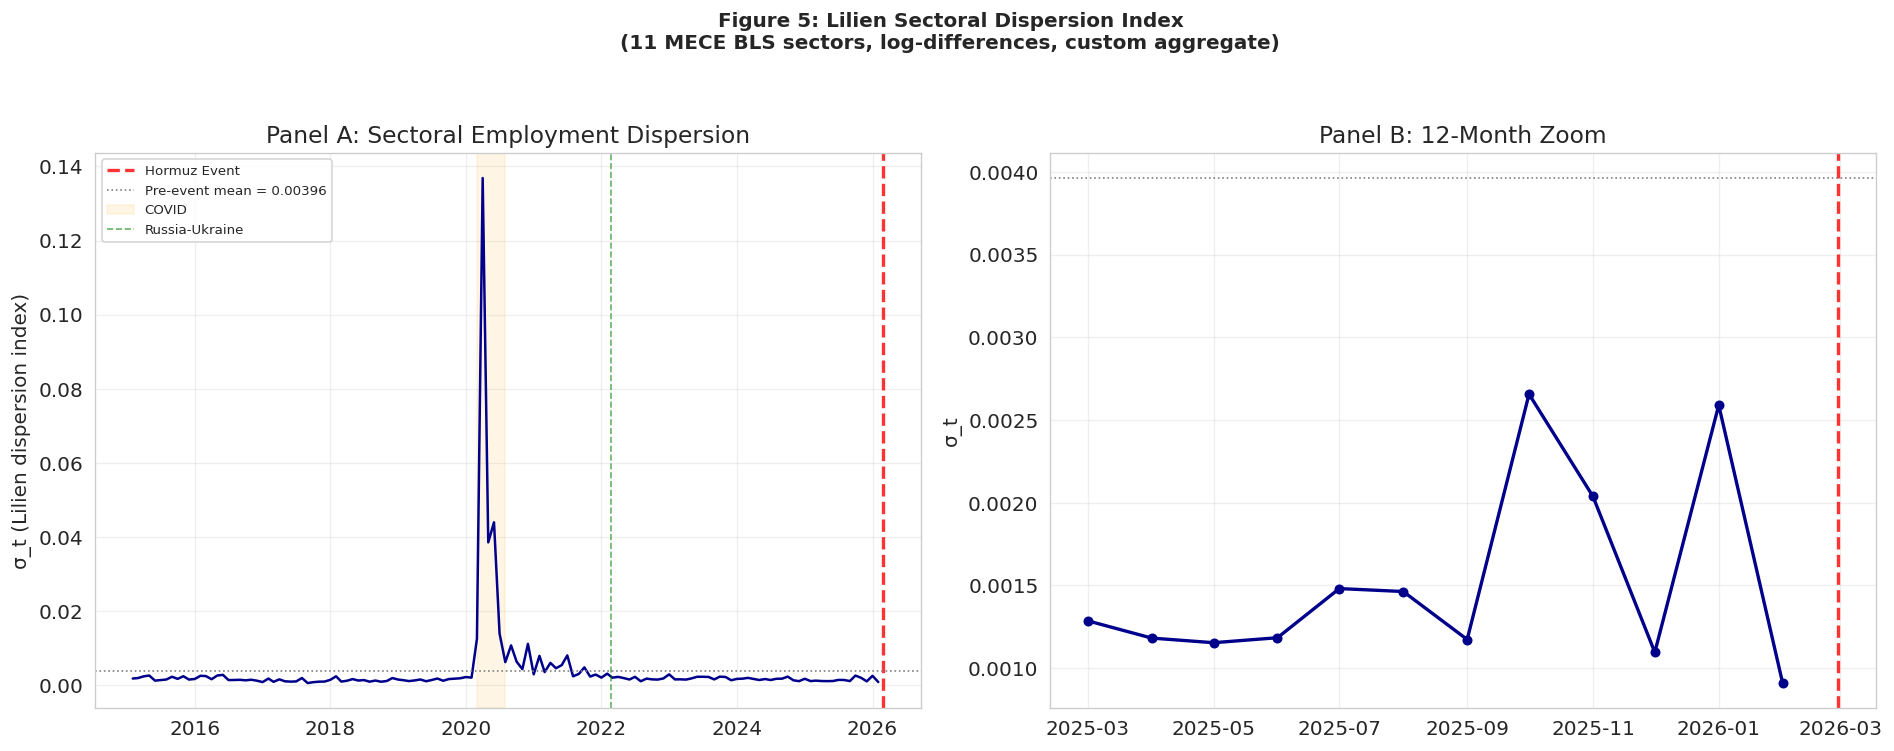


Note: Lilien index establishes historical baseline. The 2020 COVID spike
proves the mechanism. Post-Hormuz reallocation is currently accumulating
and will appear in BLS data with ~2 month lag (Fix #3).


In [23]:
# ============================================================
# 5.4  Lilien Sectoral Dispersion Index (σ_t)
#      Fix #6:  log-differences (not pct_change)
#      Fix #11: custom aggregate = Σ(11 MECE sectors)
#      Trap 2:  excludes 'Total Private' and 'Retail Trade'
# ============================================================
if not ces_df.empty:
    # Select MECE sectors only (Trap 2)
    mece_cols = [c for c in LILIEN_SECTORS if c in ces_df.columns]
    ces_mece = ces_df[mece_cols].dropna()

    if len(mece_cols) >= 8:
        print(f"Lilien index: {len(mece_cols)} MECE sectors")
        print(f"  Sectors: {mece_cols}")
        print(f"  Excluded: Total Private (parent), Retail Trade (child of TTU)")

        # Log employment growth (Fix #6: use log, not pct_change)
        log_emp_growth = np.log(ces_mece / ces_mece.shift(1)).dropna()

        # Custom aggregate = sum of MECE sectors (Fix #11)
        E_total = ces_mece.sum(axis=1)
        agg_growth = np.log(E_total / E_total.shift(1)).dropna()

        # Employment shares
        shares = ces_mece.div(E_total, axis=0)

        # Lilien index: σ_t = √[ Σ s_i * (Δlog E_i - Δlog E)² ]
        common_idx = log_emp_growth.index.intersection(agg_growth.index).intersection(shares.index)
        log_g = log_emp_growth.loc[common_idx]
        agg_g = agg_growth.loc[common_idx]
        s = shares.loc[common_idx]

        # Compute dispersion
        deviations_sq = log_g.sub(agg_g, axis=0) ** 2
        weighted_dev = deviations_sq.mul(s)
        lilien_idx = np.sqrt(weighted_dev.sum(axis=1))
        lilien_idx.name = 'Lilien_sigma'

        # Stats
        pre_event = lilien_idx[lilien_idx.index < EVENT_DATE]
        post_event = lilien_idx[lilien_idx.index >= EVENT_DATE]

        print(f"\nLilien index: {len(lilien_idx)} monthly observations")
        print(f"  Pre-event mean:  {pre_event.mean():.6f}")
        print(f"  Pre-event std:   {pre_event.std():.6f}")
        if len(post_event) > 0:
            print(f"  Post-event mean: {post_event.mean():.6f}")
            print(f"  Post-event latest: {post_event.iloc[-1]:.6f}")
        else:
            print(f"  Post-event: no data yet (BLS lag — Fix #3)")

        # Figure
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # Panel A: Full time series
        ax1.plot(lilien_idx.index, lilien_idx.values, color='darkblue', lw=1.5)
        ax1.axvline(EVENT_DATE, color='red', ls='--', lw=2, alpha=0.8, label='Hormuz Event')
        ax1.axhline(pre_event.mean(), color='gray', ls=':', lw=1,
                     label=f'Pre-event mean = {pre_event.mean():.5f}')
        # Highlight historical spikes
        if lilien_idx.index.min() <= pd.Timestamp('2020-04-01'):
            ax1.axvspan('2020-03-01', '2020-08-01', alpha=0.1, color='orange', label='COVID')
        if lilien_idx.index.min() <= pd.Timestamp('2022-03-01'):
            ax1.axvline(pd.Timestamp('2022-02-24'), color='green', ls='--', lw=1, alpha=0.6,
                        label='Russia-Ukraine')
        ax1.set_ylabel('σ_t (Lilien dispersion index)')
        ax1.set_title('Panel A: Sectoral Employment Dispersion')
        ax1.legend(fontsize=8)
        ax1.grid(True, alpha=0.3)

        # Panel B: Zoom around event
        zoom_start = EVENT_DATE - pd.DateOffset(months=12)
        zoom = lilien_idx[lilien_idx.index >= zoom_start]
        ax2.plot(zoom.index, zoom.values, color='darkblue', lw=2, marker='o', markersize=5)
        ax2.axvline(EVENT_DATE, color='red', ls='--', lw=2, alpha=0.8)
        ax2.axhline(pre_event.mean(), color='gray', ls=':', lw=1)
        ax2.set_ylabel('σ_t')
        ax2.set_title('Panel B: 12-Month Zoom')
        ax2.grid(True, alpha=0.3)

        plt.suptitle('Figure 5: Lilien Sectoral Dispersion Index\n'
                     '(11 MECE BLS sectors, log-differences, custom aggregate)',
                     fontsize=12, fontweight='bold', y=1.04)
        plt.tight_layout()
        plt.savefig('figure5_lilien.png', dpi=300, bbox_inches='tight')
        plt.show()

        print("\nNote: Lilien index establishes historical baseline. The 2020 COVID spike")
        print("proves the mechanism. Post-Hormuz reallocation is currently accumulating")
        print("and will appear in BLS data with ~2 month lag (Fix #3).")
    else:
        print(f"[WARN] Only {len(mece_cols)} MECE sectors available (need ≥8)")
        lilien_idx = pd.Series(dtype=float)
else:
    print("[WARN] No CES employment data")
    lilien_idx = pd.Series(dtype=float)

Industry VARs: Oil → Employment
  Sectors: 11
  Oil returns: 38 months
  Max lags: 3 (Fix #4)
  COVID dummy: yes (Fix #10)

Estimated 11/11 industry VARs

TABLE 3: Oil → Employment IRF Summary (Industry VARs)


,Lag,N,Peak Month,Peak Effect,Cum 6m,Cum 12m
Sector,,,,,,
Mining & Logging,3,34,2,-0.0257,-0.0056,-0.0085
Information,3,34,1,-0.0170,-0.0123,-0.0123
Other Services,3,34,3,-0.0079,-0.0062,-0.0063
Prof & Business Svcs,3,34,3,-0.0064,-0.0061,-0.0054
Construction,3,34,3,-0.0059,-0.0098,-0.0082
Government,3,34,3,-0.0056,-0.0162,-0.0282
Leisure & Hospitality,3,34,1,-0.0052,-0.0061,-0.0062
Education & Health,3,34,1,-0.0047,-0.0087,-0.0136
Financial Activities,3,34,3,0.0036,0.0005,0.0006


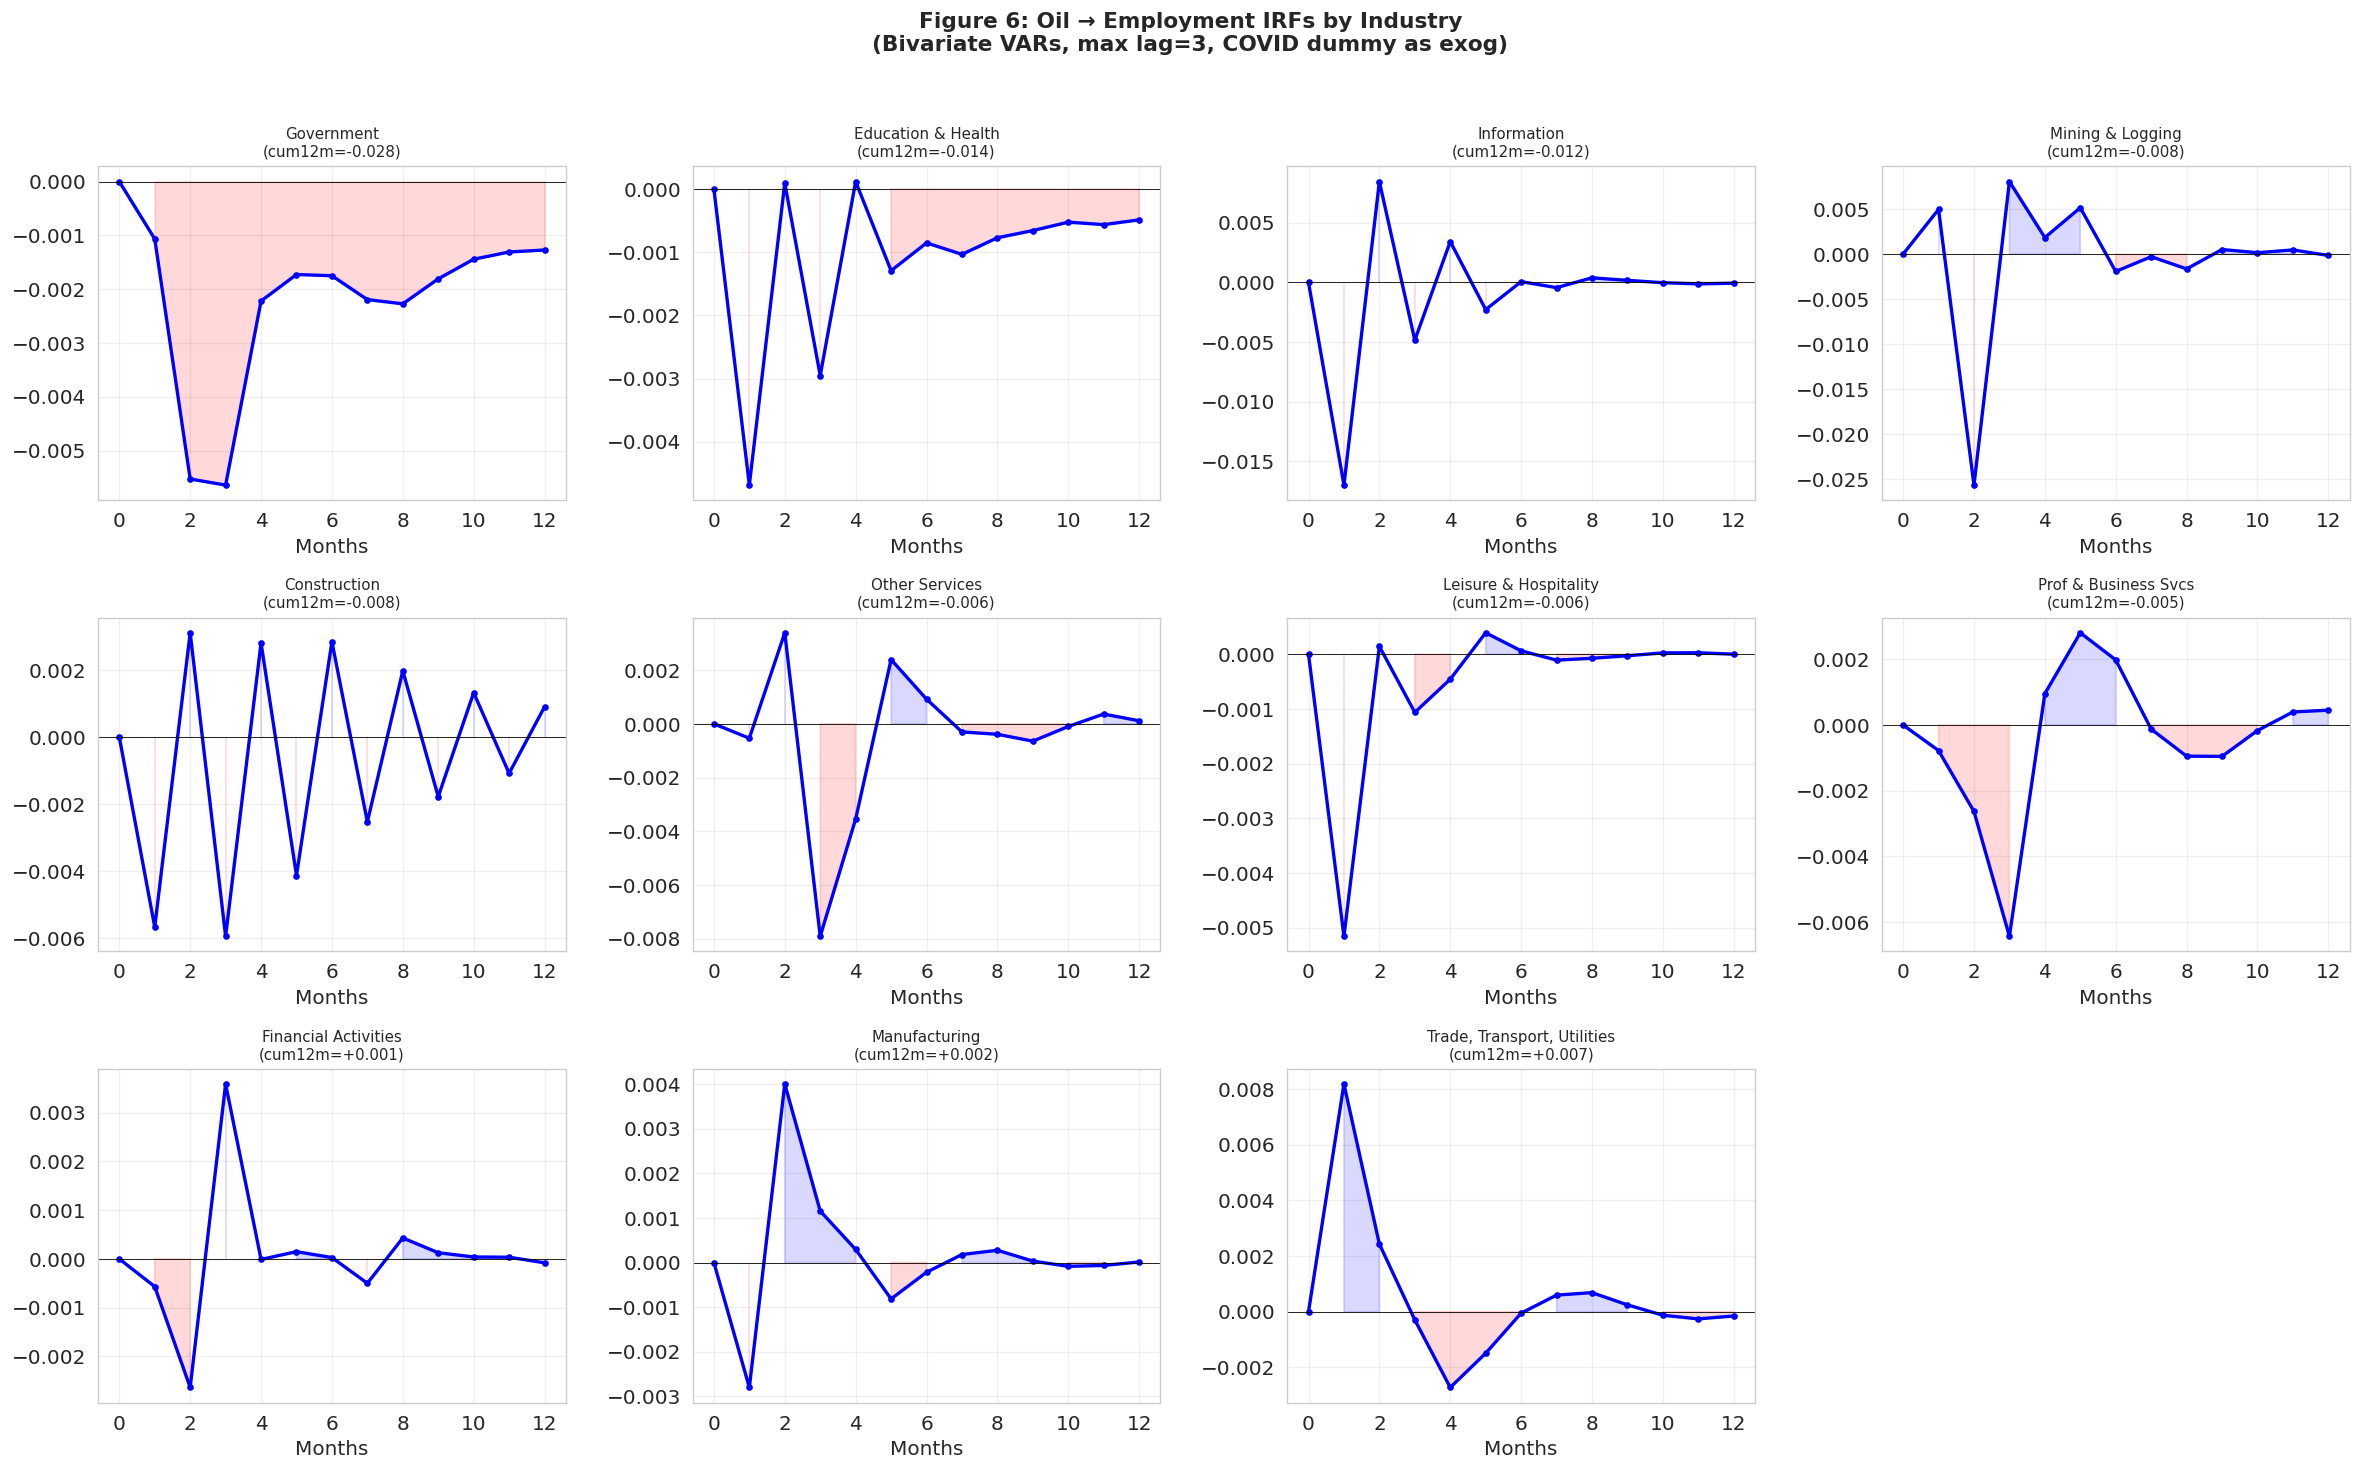

In [24]:
# ============================================================
# 5.5  Industry-Level VARs: Oil → Sectoral Employment
#      Fix #4:  maxlags=3 (prevent overfitting on short samples)
#      Fix #10: COVID dummy as exog
# ============================================================
if not ces_df.empty and 'WTI_monthly_ret' in monthly_macro.columns:
    # Log employment growth for MECE sectors
    mece_cols = [c for c in LILIEN_SECTORS if c in ces_df.columns]
    emp_log_g = np.log(ces_df[mece_cols] / ces_df[mece_cols].shift(1)).dropna() * 100

    oil_ret = monthly_macro['WTI_monthly_ret'].dropna()

    # COVID dummy aligned to employment data
    covid_emp = pd.Series(0, index=emp_log_g.index, name='COVID')
    covid_emp[(emp_log_g.index >= COVID_START) & (emp_log_g.index <= COVID_END)] = 1

    print(f"Industry VARs: Oil → Employment")
    print(f"  Sectors: {len(mece_cols)}")
    print(f"  Oil returns: {len(oil_ret)} months")
    print(f"  Max lags: 3 (Fix #4)")
    print(f"  COVID dummy: {'yes' if covid_emp.sum() > 0 else 'no'} (Fix #10)")

    ivar_results = {}

    for sector in mece_cols:
        # Build bivariate VAR: [Oil_Return, ΔEmployment_sector]
        bvar_data = pd.DataFrame({
            'Oil': oil_ret,
            f'Emp_{sector[:8]}': emp_log_g[sector]
        }).dropna()

        # COVID exog
        covid_bvar = covid_emp.reindex(bvar_data.index).fillna(0).values.reshape(-1, 1)
        has_covid = covid_bvar.sum() > 0

        if len(bvar_data) < 20:
            continue

        try:
            bvar_exog = covid_bvar if has_covid else None
            bvar_model = VAR(bvar_data, exog=bvar_exog)
            max_lag = min(3, (len(bvar_data) - 3) // 3)  # Fix #4
            if max_lag < 1:
                continue
            bvar_fit = bvar_model.fit(max_lag)
            bvar_irf = bvar_fit.irf(periods=12)

            # Oil → Employment response
            oil_idx = bvar_data.columns.get_loc('Oil')
            emp_idx = 1 - oil_idx  # the other one
            irf_vals = bvar_irf.irfs[:, emp_idx, oil_idx]

            # Peak response
            peak_idx = np.argmax(np.abs(irf_vals[1:]))  # skip contemporaneous
            peak_val = irf_vals[1 + peak_idx]
            cum_6m = irf_vals[:min(6, len(irf_vals))].sum()
            cum_12m = irf_vals.sum()

            ivar_results[sector] = {
                'irf': irf_vals,
                'peak_month': 1 + peak_idx,
                'peak_val': peak_val,
                'cum_6m': cum_6m,
                'cum_12m': cum_12m,
                'nobs': bvar_fit.nobs,
                'lag': max_lag,
            }
        except Exception as e:
            print(f"  [WARN] {sector}: {e}")
            continue

    print(f"\nEstimated {len(ivar_results)}/{len(mece_cols)} industry VARs")

    # Table
    if ivar_results:
        print(f"\n{'='*70}")
        print(f"TABLE 3: Oil → Employment IRF Summary (Industry VARs)")
        print(f"{'='*70}")
        ivar_tbl = pd.DataFrame([
            {'Sector': sec, 'Lag': r['lag'], 'N': r['nobs'],
             'Peak Month': r['peak_month'], 'Peak Effect': round(r['peak_val'], 4),
             'Cum 6m': round(r['cum_6m'], 4), 'Cum 12m': round(r['cum_12m'], 4)}
            for sec, r in ivar_results.items()
        ]).sort_values('Peak Effect')
        display(ivar_tbl.set_index('Sector'))

        # Figure: IRF grid
        n_sectors = len(ivar_results)
        ncols = min(4, n_sectors)
        nrows = (n_sectors + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
        axes_flat = np.array(axes).flatten() if n_sectors > 1 else [axes]

        for i, (sector, r) in enumerate(sorted(ivar_results.items(),
                                                 key=lambda x: x[1]['cum_12m'])):
            ax = axes_flat[i]
            vals = r['irf']
            ax.plot(range(len(vals)), vals, 'b-', lw=2, marker='o', markersize=3)
            ax.axhline(0, color='black', lw=0.5)
            ax.fill_between(range(len(vals)), vals, 0,
                            where=vals < 0, alpha=0.15, color='red')
            ax.fill_between(range(len(vals)), vals, 0,
                            where=vals > 0, alpha=0.15, color='blue')
            ax.set_title(f'{sector}\n(cum12m={r["cum_12m"]:+.3f})', fontsize=9)
            ax.set_xlabel('Months')
            ax.grid(True, alpha=0.3)

        for j in range(i + 1, len(axes_flat)):
            axes_flat[j].set_visible(False)

        plt.suptitle(f'Figure 6: Oil → Employment IRFs by Industry\n'
                     f'(Bivariate VARs, max lag=3, COVID dummy as exog)',
                     fontsize=13, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig('figure6_industry_irf.png', dpi=300, bbox_inches='tight')
        plt.show()
else:
    print("[INFO] Need BLS + oil data for industry VARs")
    ivar_results = {}

---
## Section 6: Cross-Sectional Analysis + Data Status

Data coverage is computed dynamically below based on what was actually fetched.

DATA STATUS REPORT — Run: 2026-03-18
Days since event: 18


,Source,Series,Latest,N,Post-event?
0,FRED,USEPUINDXD,2026-03-16,1171,Yes
1,FRED,DCOILWTICO,2026-03-09,791,Yes
2,FRED,VIXCLS,2026-03-16,826,Yes
3,FRED,DGS10,2026-03-16,799,Yes
4,yfinance,37 ETFs,2026-03-17,2062,Yes
5,BLS Empl,13 series,2026-02-01,134,No
6,BLS CPI,7 series,2026-02-01,134,No
7,BLS PPI,6 series,2026-01-01,133,No
8,FRED Monthly,INDPRO,2026-02-01,38,No
9,FRED Monthly,UNRATE,2026-02-01,37,No



5/11 sources have post-event data

TABLE S1 (Supplementary): Sector Characteristics vs. CARs (Window: [-10, +10])
               Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
const      -0.222123  1.132379 -0.196156  0.844488 -2.441545  1.997299
Energy_Int  3.795438  1.900446  1.997130  0.045811  0.070632  7.520245
Trade_Exp  -0.632964  1.774553 -0.356689  0.721325 -4.111024  2.845096
Labor_Int   1.237190  1.809078  0.683879  0.494052 -2.308537  4.782918
Oil_Sens   -0.312013  2.036792 -0.153188  0.878250 -4.304051  3.680025

R²=0.485  Adj R²=0.142  N=11

ROBUSTNESS: R² and key coefficients across 7 windows
Window              R²   Energy_Int    Trade_Exp
[0, +1]          0.167     -0.038       -0.016  
[-1, +1]         0.541     -0.027       -0.512  
[-3, +1]         0.441     -0.131       -0.834  
[-3, +2]         0.245     +0.308       -0.717  
[-3, +3]         0.149     +0.826       -0.443  
[-5, +5]         0.305     +1.684       -0.516  
[-10, +10]       0.485     +3.79

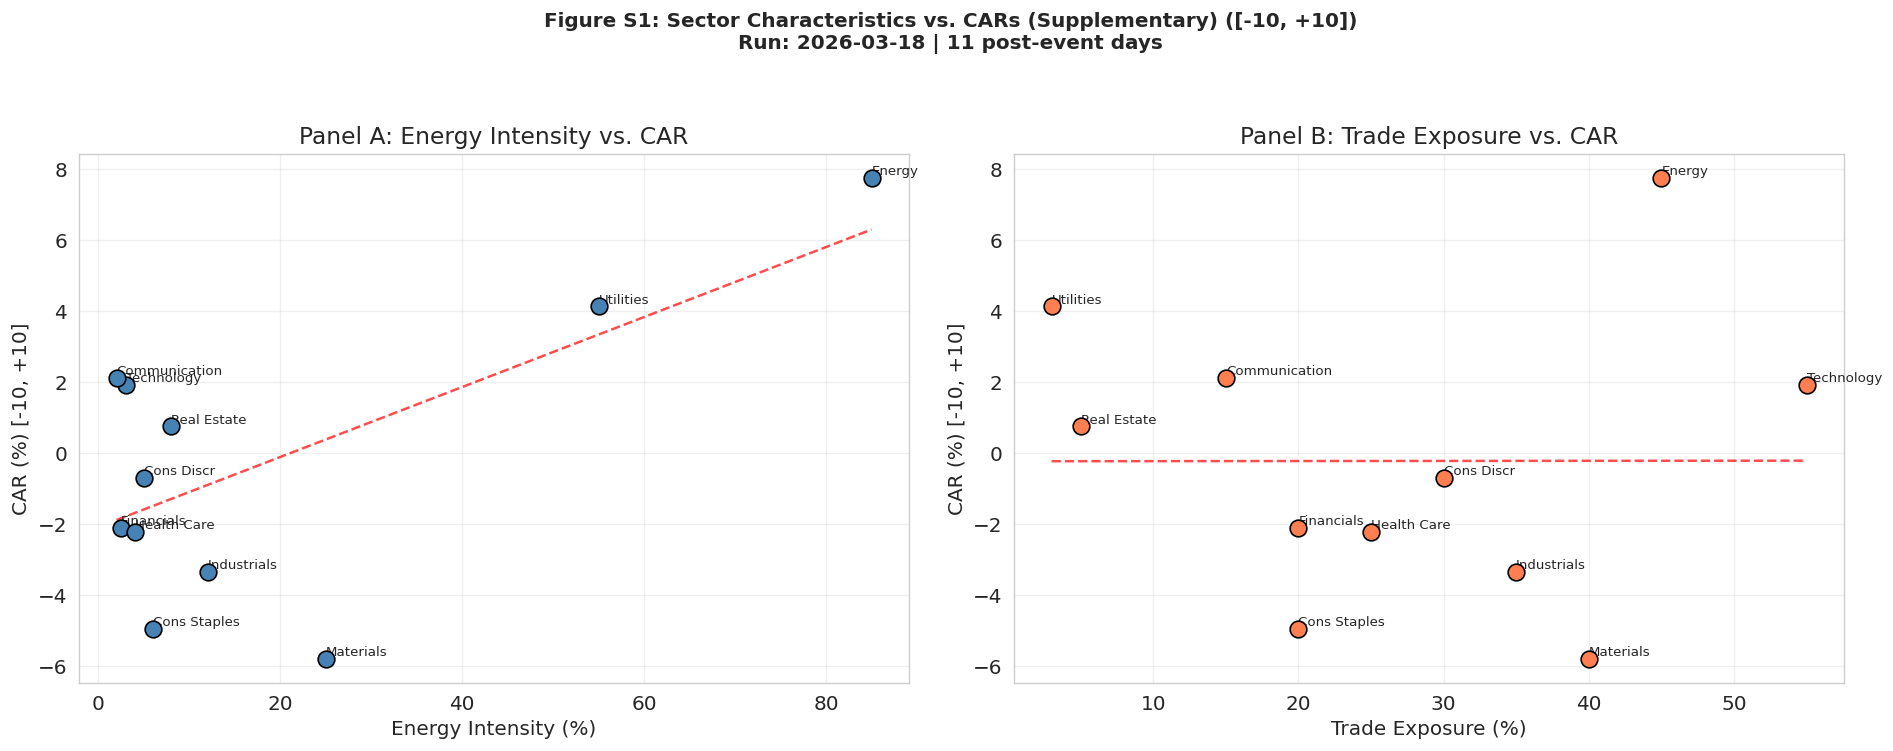

In [25]:
# ============================================================
# 6.1  Data Status Report + Cross-Sectional Regression
#      ROBUST: Dynamically reports what data is available
# ============================================================

# --- DATA STATUS ---
print("=" * 70)
print(f"DATA STATUS REPORT — Run: {RUN_DATE.date()}")
print(f"Days since event: {days_since_event}")
print("=" * 70)

status_rows = []
if not fred_daily_df.empty:
    for col in ['USEPUINDXD', 'DCOILWTICO', 'VIXCLS', 'DGS10']:
        if col in fred_daily_df.columns:
            s = fred_daily_df[col].dropna()
            if not s.empty:
                status_rows.append({'Source': 'FRED', 'Series': col,
                    'Latest': str(s.index.max().date()), 'N': len(s),
                    'Post-event?': 'Yes' if s.index.max() >= EVENT_DATE else 'No'})

if not etf_df.empty:
    status_rows.append({'Source': 'yfinance', 'Series': f'{etf_df.shape[1]} ETFs',
        'Latest': str(etf_df.index.max().date()), 'N': len(etf_df),
        'Post-event?': 'Yes' if etf_df.index.max() >= EVENT_DATE else 'No'})

for name, df in [('BLS Empl', ces_df), ('BLS CPI', cpi_df), ('BLS PPI', ppi_df)]:
    if not df.empty:
        status_rows.append({'Source': name, 'Series': f'{df.shape[1]} series',
            'Latest': str(df.index.max().date()), 'N': len(df),
            'Post-event?': 'Yes' if df.index.max() >= EVENT_DATE else 'No'})

if not fred_monthly_df.empty:
    for col in ['INDPRO', 'UNRATE', 'CPIAUCSL']:
        if col in fred_monthly_df.columns:
            s = fred_monthly_df[col].dropna()
            if not s.empty:
                status_rows.append({'Source': 'FRED Monthly', 'Series': col,
                    'Latest': str(s.index.max().date()), 'N': len(s),
                    'Post-event?': 'Yes' if s.index.max() >= EVENT_DATE else 'No'})

if status_rows:
    status_df = pd.DataFrame(status_rows)
    display(status_df)
    n_post_sources = sum(1 for r in status_rows if r['Post-event?'] == 'Yes')
    print(f"\n{n_post_sources}/{len(status_rows)} sources have post-event data")

# --- CROSS-SECTIONAL REGRESSION (Supplementary: sector characteristics) ---
# NOTE: Primary β_oil cross-section is in Cell 20. This uses hardcoded sector traits.
print(f"\n{'=' * 70}")
print(f"TABLE S1 (Supplementary): Sector Characteristics vs. CARs (Window: {primary_window})")
print("=" * 70)

sc = pd.DataFrame({
    'Ticker': ['XLE','XLF','XLI','XLK','XLV','XLC','XLB','XLRE','XLU','XLP','XLY'],
    'Sector': ['Energy','Financials','Industrials','Technology','Health Care',
               'Communication','Materials','Real Estate','Utilities','Cons Staples','Cons Discr'],
    'Energy_Int': [85, 2.5, 12, 3, 4, 2, 25, 8, 55, 6, 5],
    'Trade_Exp':  [45, 20, 35, 55, 25, 15, 40, 5, 3, 20, 30],
    'Labor_Int':  [8, 35, 30, 40, 50, 30, 15, 10, 15, 20, 35],
    'Oil_Sens':   [.8, -.1, -.15, -.2, -.05, -.08, .15, -.12, -.05, -.08, -.25],
}).set_index('Ticker')

if all_window_results:
    # Add CARs from ALL windows
    for wname in windows.keys():
        col = f'CAR_{wname}'
        sc[col] = sc.index.map(
            lambda x, w=wname: all_window_results[w][x]['CAR_total'] * 100
            if x in all_window_results[w] else np.nan)

    sc['Beta'] = sc.index.map(lambda x: event_results[x]['beta'] if x in event_results else np.nan)
    primary_col = f'CAR_{primary_window}'
    sc['CAR'] = sc[primary_col]

    reg = sc.dropna(subset=['CAR'])
    xvars = ['Energy_Int', 'Trade_Exp', 'Labor_Int', 'Oil_Sens']
    X = reg[xvars]
    X_std = (X - X.mean()) / X.std()
    X_std = sm.add_constant(X_std)
    y = reg['CAR']
    ols = sm.OLS(y, X_std).fit(cov_type='HC1')

    print(ols.summary2().tables[1].to_string())
    print(f"\nR²={ols.rsquared:.3f}  Adj R²={ols.rsquared_adj:.3f}  N={int(ols.nobs)}")

    # Robustness across windows
    print(f"\n{'=' * 70}")
    print(f"ROBUSTNESS: R² and key coefficients across {len(windows)} windows")
    print(f"{'=' * 70}")
    print(f"{'Window':<15s} {'R²':>6s} {'Energy_Int':>12s} {'Trade_Exp':>12s}")
    for wname in windows.keys():
        wcar_col = f'CAR_{wname}'
        if wcar_col in reg.columns:
            y_w = reg[wcar_col].dropna()
            if len(y_w) >= 6:
                ols_w = sm.OLS(y_w, X_std.loc[y_w.index]).fit(cov_type='HC1')
                ei = ols_w.params.get('Energy_Int', np.nan)
                te = ols_w.params.get('Trade_Exp', np.nan)
                ei_s = "***" if ols_w.pvalues.get('Energy_Int',1)<.01 else "**" if ols_w.pvalues.get('Energy_Int',1)<.05 else "*" if ols_w.pvalues.get('Energy_Int',1)<.1 else ""
                te_s = "***" if ols_w.pvalues.get('Trade_Exp',1)<.01 else "**" if ols_w.pvalues.get('Trade_Exp',1)<.05 else "*" if ols_w.pvalues.get('Trade_Exp',1)<.1 else ""
                print(f"{wname:<15s} {ols_w.rsquared:6.3f} {ei:+10.3f}{ei_s:2s} {te:+10.3f}{te_s:2s}")

    # Figure 3
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    for ax, xvar, xlabel, color in [(ax1, 'Energy_Int', 'Energy Intensity (%)', 'steelblue'),
                                     (ax2, 'Trade_Exp', 'Trade Exposure (%)', 'coral')]:
        ax.scatter(reg[xvar], reg['CAR'], s=100, c=color, edgecolor='black', zorder=5)
        for _, r in reg.iterrows():
            ax.annotate(r['Sector'], (r[xvar], r['CAR']), fontsize=8, ha='left', va='bottom')
        z = np.polyfit(reg[xvar], reg['CAR'], 1)
        xl = np.linspace(reg[xvar].min(), reg[xvar].max(), 100)
        ax.plot(xl, np.poly1d(z)(xl), 'r--', alpha=.7)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(f'CAR (%) {primary_window}')
        ax.grid(True, alpha=.3)
    ax1.set_title('Panel A: Energy Intensity vs. CAR')
    ax2.set_title('Panel B: Trade Exposure vs. CAR')
    plt.suptitle(f'Figure S1: Sector Characteristics vs. CARs (Supplementary) ({primary_window})\n'
                 f'Run: {RUN_DATE.date()} | {n_post} post-event days',
                 fontsize=12, fontweight='bold', y=1.04)
    plt.tight_layout()
    plt.savefig('figure3b_sector_chars.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("[INFO] Need event study results first")

In [26]:
# ============================================================
# 6.2  BONUS: Download actual GPR Index  [CACHED]
#      Caldara & Iacoviello (updated 2026-03-03!)
#      This is the REAL geopolitical risk index (not EPU).
# ============================================================
if cache_is_fresh('gpr_daily') and cache_is_fresh('gpr_monthly'):
    gpr_daily_raw = load_from_cache('gpr_daily')
    gpr_monthly_raw = load_from_cache('gpr_monthly')
    GPR_AVAILABLE = True
    print(f"  GPR daily:   {gpr_daily_raw.shape}")
    print(f"  GPR monthly: {gpr_monthly_raw.shape}")
    display(gpr_daily_raw.tail())
    display(gpr_monthly_raw.tail())
else:
    print("Downloading Caldara-Iacoviello GPR Index (direct from source) ...")
    try:
        gpr_daily_url = "https://www.matteoiacoviello.com/gpr_files/data_gpr_daily_recent.xls"
        gpr_daily_raw = pd.read_excel(gpr_daily_url)
        print(f"  GPR daily raw: {gpr_daily_raw.shape}")
        print(f"  Columns: {list(gpr_daily_raw.columns)}")

        date_col = [c for c in gpr_daily_raw.columns if 'date' in str(c).lower()]
        if date_col:
            gpr_daily_raw[date_col[0]] = pd.to_datetime(gpr_daily_raw[date_col[0]])
            gpr_daily_raw = gpr_daily_raw.set_index(date_col[0]).sort_index()
        gpr_daily_raw = gpr_daily_raw.loc[SAMPLE_START:SAMPLE_END]
        print(f"  After filtering: {gpr_daily_raw.shape}")
        print(f"  Date range: {gpr_daily_raw.index.min().date()} to {gpr_daily_raw.index.max().date()}")
        save_to_cache('gpr_daily', gpr_daily_raw)
        display(gpr_daily_raw.tail())

        gpr_monthly_url = "https://www.matteoiacoviello.com/gpr_files/data_gpr_export.xls"
        gpr_monthly_raw = pd.read_excel(gpr_monthly_url)
        print(f"\n  GPR monthly raw: {gpr_monthly_raw.shape}")
        date_col2 = [c for c in gpr_monthly_raw.columns if 'date' in str(c).lower() or 'month' in str(c).lower()]
        if date_col2:
            gpr_monthly_raw[date_col2[0]] = pd.to_datetime(gpr_monthly_raw[date_col2[0]])
            gpr_monthly_raw = gpr_monthly_raw.set_index(date_col2[0]).sort_index()
        gpr_monthly_raw = gpr_monthly_raw.loc[SAMPLE_START:SAMPLE_END]
        print(f"  After filtering: {gpr_monthly_raw.shape}")
        save_to_cache('gpr_monthly', gpr_monthly_raw)
        display(gpr_monthly_raw.tail())

        GPR_AVAILABLE = True
    except Exception as e:
        print(f"  [WARN] Could not download GPR data: {e}")
        print("  Falling back to EPU index (already loaded from FRED)")
        GPR_AVAILABLE = False

  [CACHE] Loaded gpr_daily (0.2h old)  (1171, 10)
  [CACHE] Loaded gpr_monthly (0.2h old)  (38, 114)
  GPR daily:   (1171, 10)
  GPR monthly: (38, 114)


,DAY,N10D,GPRD,GPRD_ACT,GPRD_THREAT,GPRD_MA30,GPRD_MA7,event,var_name,var_label
date,,,,,,,,,,
2026-03-12,20260312,594,295.565796,422.525604,250.409439,228.075806,346.521881,NaN,NaN,NaN
2026-03-13,20260313,530,318.756531,548.318237,207.887085,235.132736,344.241486,NaN,NaN,NaN
2026-03-14,20260314,494,348.691345,481.317261,356.858795,242.567474,354.383057,NaN,NaN,NaN
2026-03-15,20260315,404,278.780426,441.406067,204.542358,247.967178,359.316742,NaN,NaN,NaN
2026-03-16,20260316,426,248.831375,341.089996,271.570801,253.961166,335.828217,NaN,NaN,NaN


,GPR,GPRT,GPRA,GPRH,GPRHT,GPRHA,SHARE_GPR,N10,SHARE_GPRH,N3H,...,GPRHC_TUN,GPRHC_TUR,GPRHC_TWN,GPRHC_UKR,GPRHC_USA,GPRHC_VEN,GPRHC_VNM,GPRHC_ZAF,var_name,var_label
month,,,,,,,,,,,,,,,,,,,,,
2025-10-01,154.435577,168.799133,149.261887,132.678070,166.271820,122.520813,4.632116,14896.0,4.786263,8211,...,0.012179,0.292291,0.170503,0.755085,3.215199,0.621118,0.024358,0.085251,NaN,NaN
2025-11-01,104.411270,118.654984,88.926468,90.522110,119.104622,77.962738,3.131695,15870.0,3.265518,7717,...,0.000000,0.194376,0.129584,0.518336,2.164053,0.505378,0.077750,0.090709,NaN,NaN
2025-12-01,130.887665,144.223389,122.132919,112.340988,142.124802,99.599037,3.925824,15207.0,4.052618,7526,...,0.000000,0.159447,0.225884,0.876960,2.870050,0.571353,0.039862,0.039862,NaN,NaN
2026-01-01,167.668213,219.089249,99.685295,128.070435,198.120316,70.965256,5.029014,16027.0,4.620046,7922,...,0.025246,0.302954,0.151477,0.858369,3.395607,1.439031,0.012623,0.012623,NaN,NaN
2026-02-01,116.704086,149.565552,84.023399,108.117966,158.669464,73.919144,3.500404,13627.0,3.900275,6538,...,0.000000,0.321199,0.152952,0.718874,2.875497,0.672989,0.107066,0.015295,NaN,NaN


---
## Section 7: Descriptive Visualizations

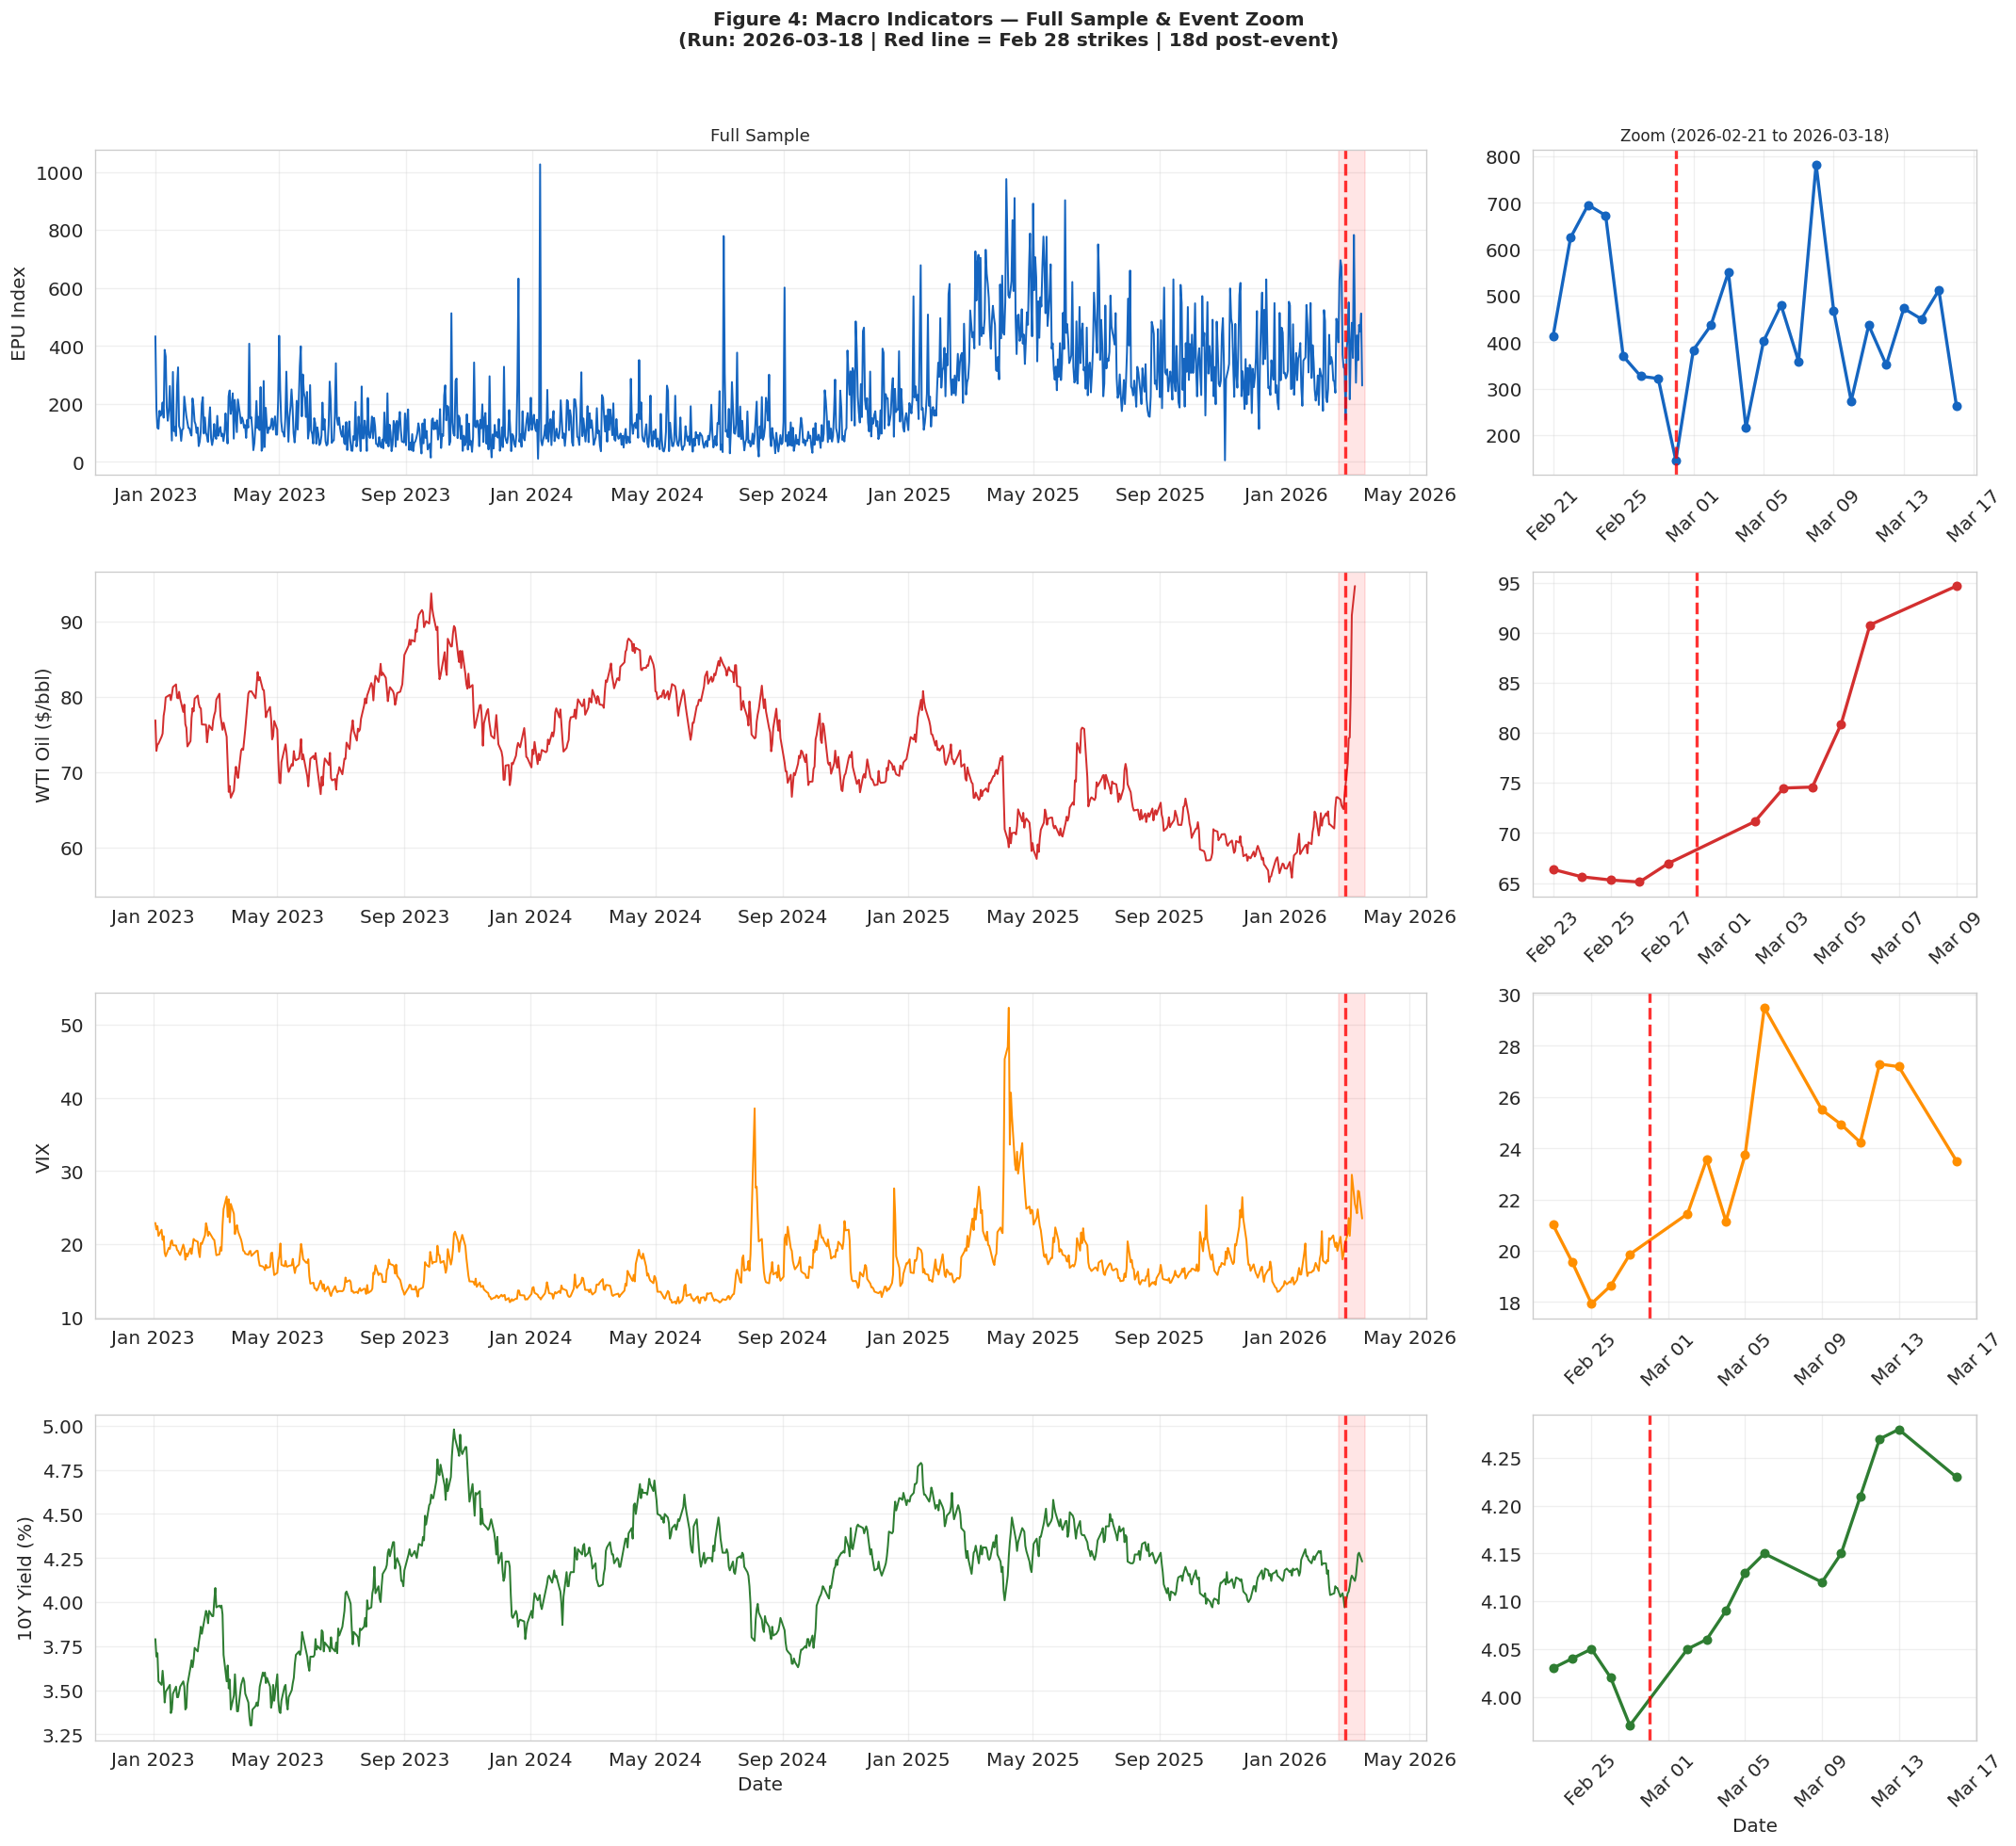

In [27]:
# ============================================================
# 7.1  Figure 4: Macro Context + Shock Zoom (Dynamic)
#      Zoom window auto-expands as more post-event data arrives
# ============================================================
plot_info = []
if 'USEPUINDXD' in fred_daily_df: plot_info.append(('USEPUINDXD', 'EPU Index', '#1565c0'))
if 'DCOILWTICO' in fred_daily_df: plot_info.append(('DCOILWTICO', 'WTI Oil ($/bbl)', '#d32f2f'))
if 'VIXCLS' in fred_daily_df: plot_info.append(('VIXCLS', 'VIX', '#ff8f00'))
if 'DGS10' in fred_daily_df: plot_info.append(('DGS10', '10Y Yield (%)', '#2e7d32'))

if plot_info:
    fig, axes = plt.subplots(len(plot_info), 2, figsize=(18, 4 * len(plot_info)),
                              gridspec_kw={'width_ratios': [3, 1]})
    if len(plot_info) == 1: axes = axes.reshape(1, -1)

    # Dynamic zoom: 7 days before event to today
    zoom_start = EVENT_DATE - pd.Timedelta(days=7)
    zoom_end = RUN_DATE + pd.Timedelta(days=1)

    for i, (col, label, color) in enumerate(plot_info):
        d = fred_daily_df[col].dropna()
        if d.empty: continue

        ax_l = axes[i, 0]
        ax_l.plot(d.index, d.values, color=color, lw=1.2)
        ax_l.axvline(EVENT_DATE, color='red', ls='--', lw=2, alpha=.8)
        ax_l.axvspan(zoom_start, zoom_end, alpha=0.1, color='red')
        ax_l.set_ylabel(label)
        ax_l.grid(True, alpha=.3)
        ax_l.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        if i == 0: ax_l.set_title('Full Sample', fontsize=11)

        ax_r = axes[i, 1]
        d_zoom = d[(d.index >= zoom_start) & (d.index <= zoom_end)]
        if not d_zoom.empty:
            ax_r.plot(d_zoom.index, d_zoom.values, color=color, lw=2, marker='o', markersize=5)
            ax_r.axvline(EVENT_DATE, color='red', ls='--', lw=2, alpha=.8)
            ax_r.tick_params(axis='x', rotation=45)
            ax_r.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
            ax_r.grid(True, alpha=.3)
        if i == 0: ax_r.set_title(f'Zoom ({zoom_start.date()} to {RUN_DATE.date()})', fontsize=10)

    axes[-1, 0].set_xlabel('Date')
    axes[-1, 1].set_xlabel('Date')
    plt.suptitle(f'Figure 4: Macro Indicators — Full Sample & Event Zoom\n'
                 f'(Run: {RUN_DATE.date()} | Red line = Feb 28 strikes | {days_since_event}d post-event)',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('figure4_macro.png', dpi=300, bbox_inches='tight')
    plt.show()

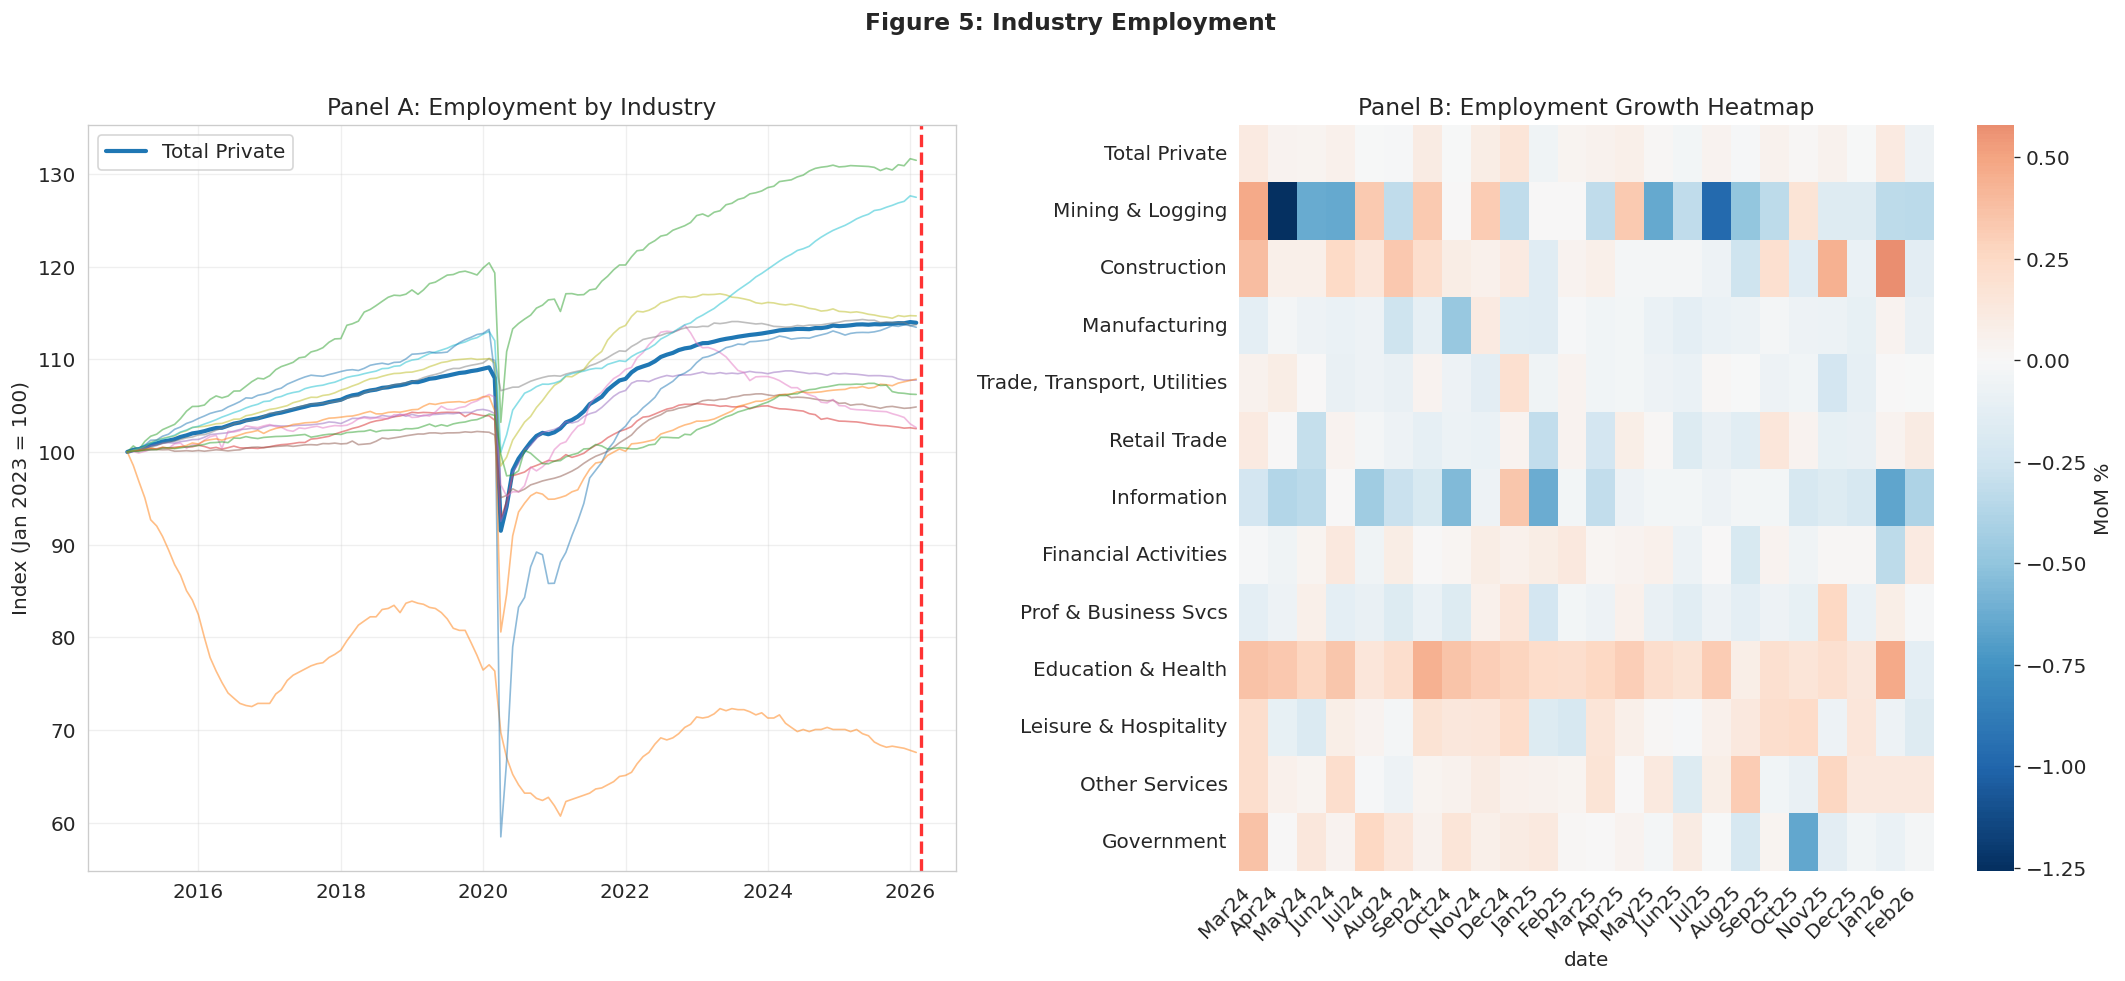

In [28]:
# ============================================================
# 7.2  Figure 5: Employment by Industry (indexed + heatmap)
# ============================================================
if not ces_df.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

    # Panel A: Indexed employment
    idx = (ces_df / ces_df.iloc[0]) * 100
    for col in idx.columns:
        lw = 2.5 if col == 'Total Private' else 1
        al = 1.0 if col == 'Total Private' else .5
        ax1.plot(idx.index, idx[col], lw=lw, alpha=al,
                label=col if col == 'Total Private' else None)
    ax1.axvline(EVENT_DATE, color='red', ls='--', lw=2, alpha=.8)
    ax1.set_ylabel('Index (Jan 2023 = 100)'); ax1.legend()
    ax1.set_title('Panel A: Employment by Industry')
    ax1.grid(True, alpha=.3)

    # Panel B: Heatmap
    hm = emp_growth.dropna().T
    if hm.shape[1] > 24: hm = hm.iloc[:, -24:]
    sns.heatmap(hm, cmap='RdBu_r', center=0, ax=ax2,
                xticklabels=[d.strftime('%b%y') for d in hm.columns],
                cbar_kws={'label':'MoM %'})
    ax2.set_title('Panel B: Employment Growth Heatmap')
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

    plt.suptitle('Figure 5: Industry Employment', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('figure5_employment.png', dpi=300, bbox_inches='tight')
    plt.show()

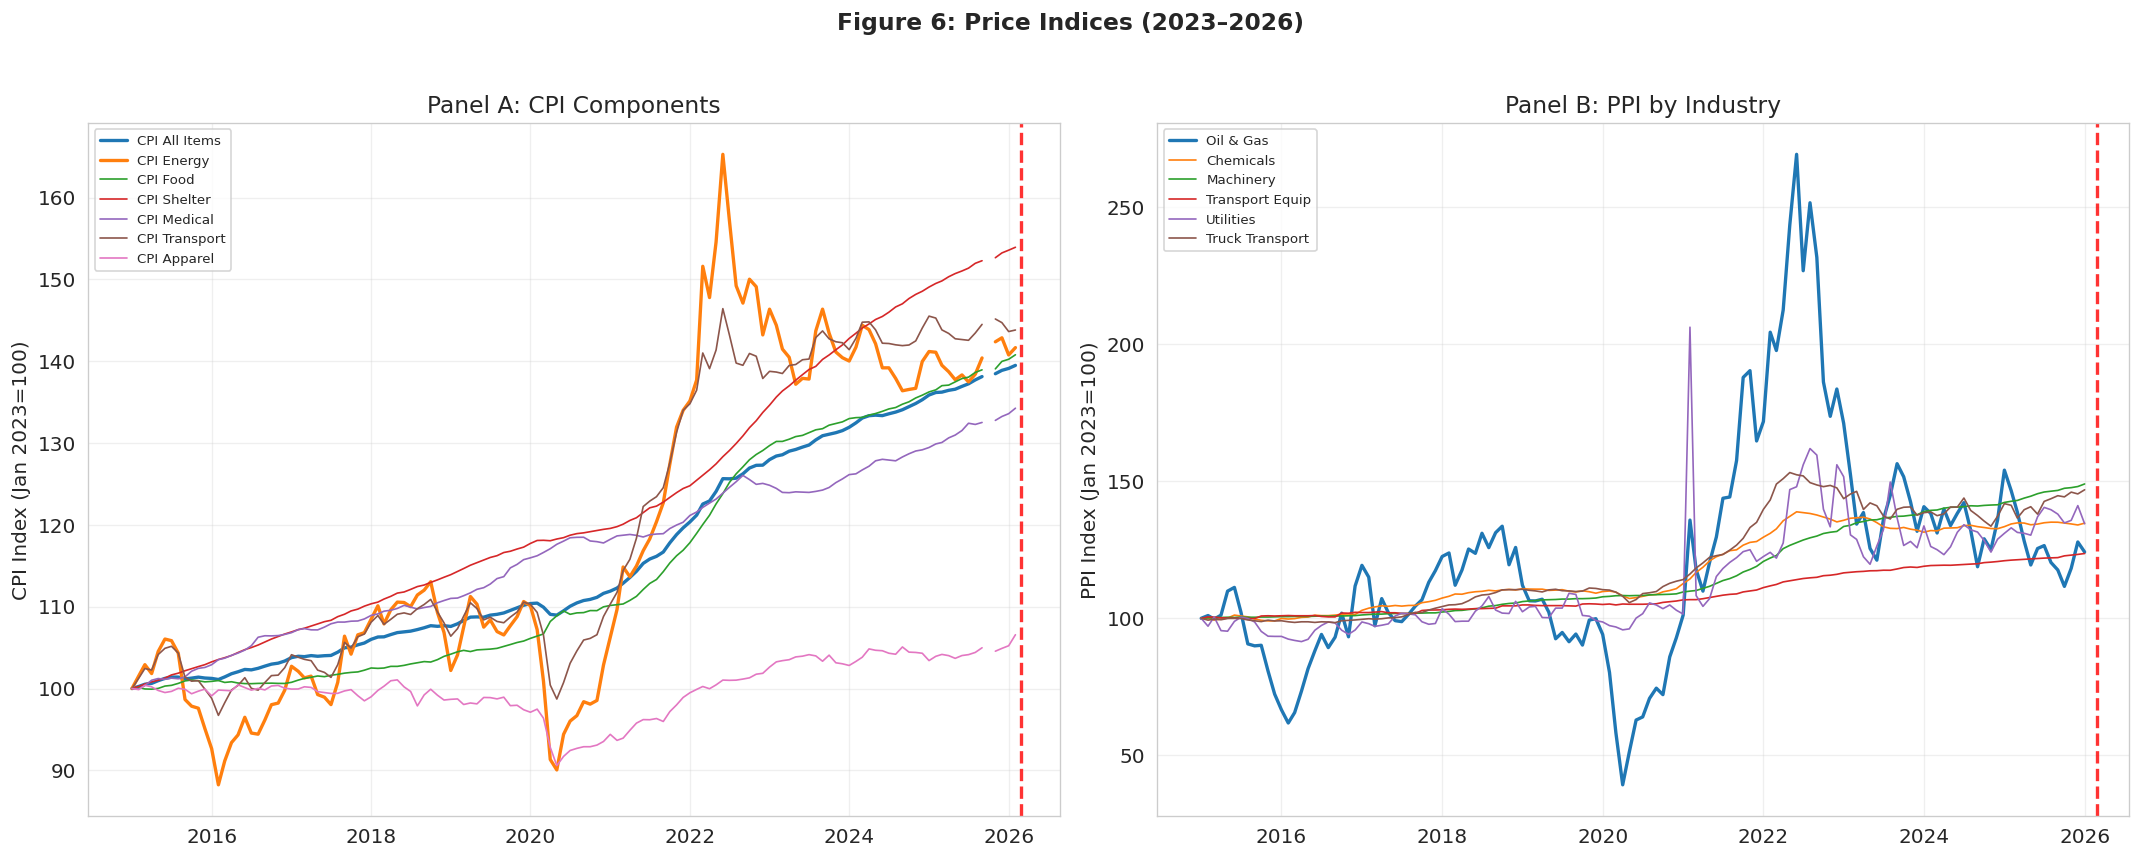

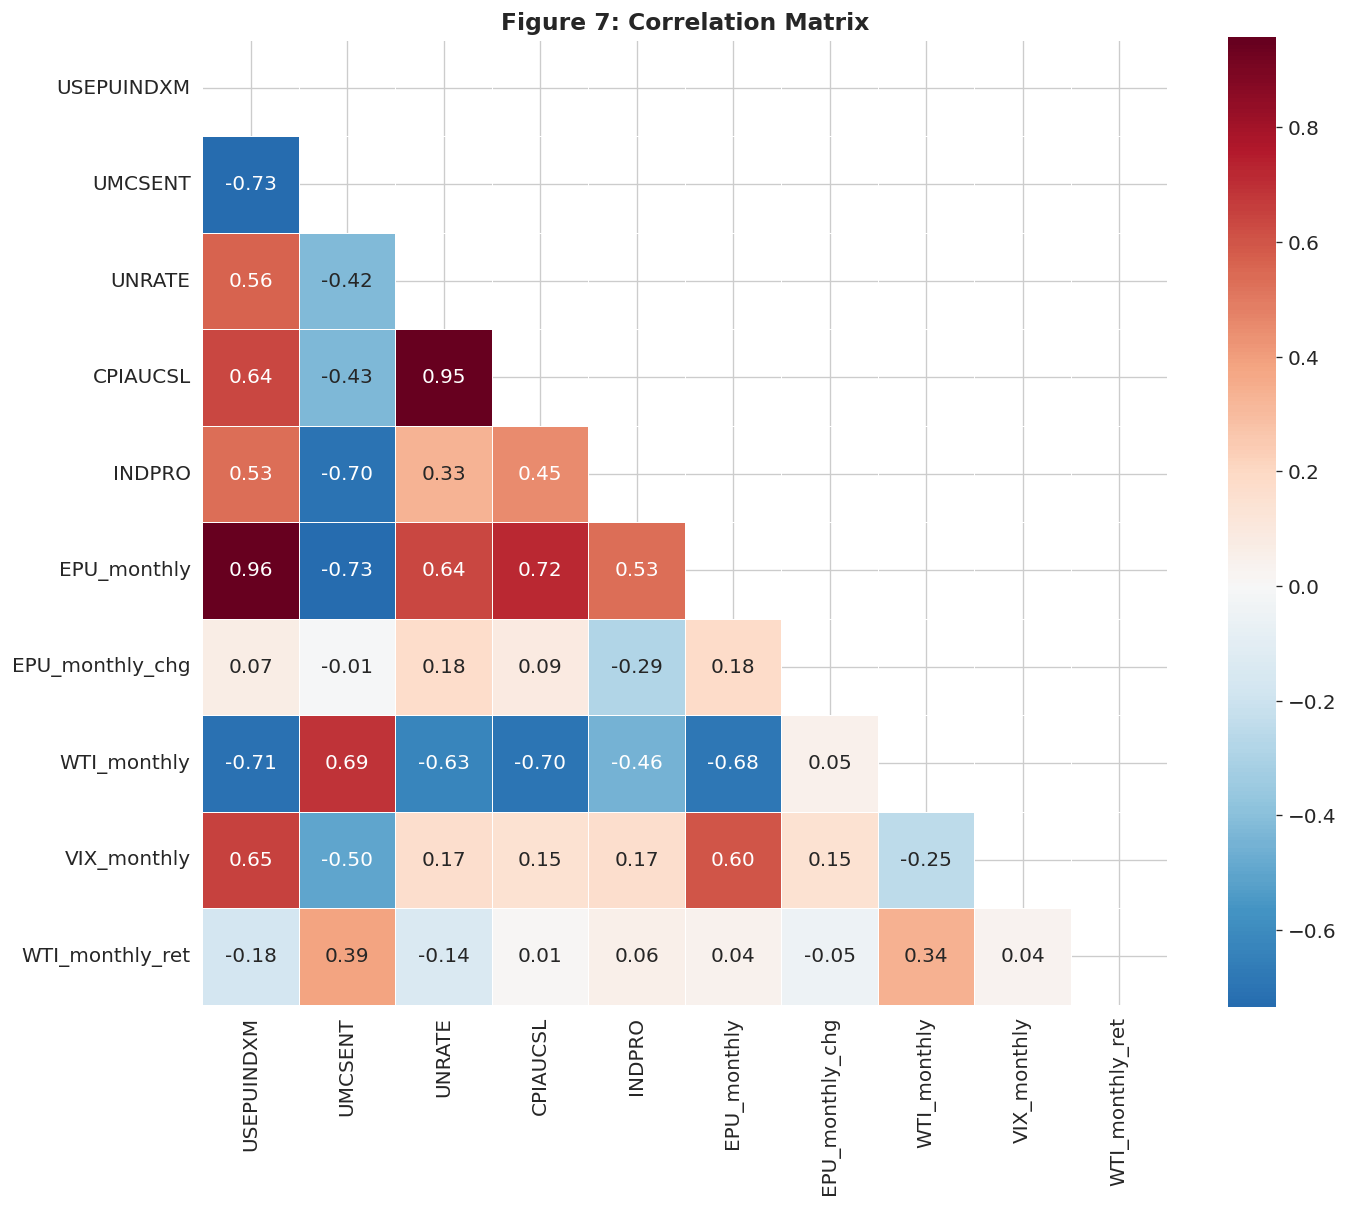

In [29]:
# ============================================================
# 7.3  Figure 6: CPI and PPI + Figure 7: Correlation Matrix
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

if not cpi_df.empty:
    ci = (cpi_df / cpi_df.iloc[0]) * 100
    for col in ci.columns:
        lw = 2 if 'Energy' in col or 'All' in col else 1
        ax1.plot(ci.index, ci[col], lw=lw, label=col)
    ax1.axvline(EVENT_DATE, color='red', ls='--', lw=2, alpha=.8)
    ax1.set_ylabel('CPI Index (Jan 2023=100)'); ax1.legend(fontsize=8)
    ax1.set_title('Panel A: CPI Components'); ax1.grid(True, alpha=.3)

if not ppi_df.empty:
    pi = (ppi_df / ppi_df.iloc[0]) * 100
    for col in pi.columns:
        lw = 2 if 'Oil' in col else 1
        ax2.plot(pi.index, pi[col], lw=lw, label=col.replace('PPI ',''))
    ax2.axvline(EVENT_DATE, color='red', ls='--', lw=2, alpha=.8)
    ax2.set_ylabel('PPI Index (Jan 2023=100)'); ax2.legend(fontsize=8)
    ax2.set_title('Panel B: PPI by Industry'); ax2.grid(True, alpha=.3)

plt.suptitle('Figure 6: Price Indices (2023–2026)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure6_prices.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation heatmap
if not monthly_macro.empty:
    cc = [c for c in monthly_macro.columns if c != 'post_event' and monthly_macro[c].notna().sum() > 10]
    if len(cc) >= 3:
        corr = monthly_macro[cc].corr()
        fig, ax = plt.subplots(figsize=(12, 10))
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, annot=True,
                   fmt='.2f', square=True, ax=ax, linewidths=.5)
        ax.set_title('Figure 7: Correlation Matrix', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('figure7_correlation.png', dpi=300, bbox_inches='tight')
        plt.show()

---
## Summary — Auto-Generated Report

In [30]:
# ============================================================
# AUTO-GENERATED SUMMARY (adapts on every re-run)
# ============================================================
print("=" * 70)
print(f"ANALYSIS SUMMARY")
print(f"Run date:         {RUN_DATE.date()}")
print(f"Event date:       {EVENT_DATE.date()} (Feb 28, 2026)")
print(f"Days since event: {days_since_event}")
print(f"Post-event trading days: {n_post}")
print("=" * 70)

# Phase detection
if days_since_event <= 7:
    phase = "IMMEDIATE (< 1 week)"
    phase_note = "Very early — only high-frequency financial data available"
elif days_since_event <= 30:
    phase = "SHORT-TERM (1-4 weeks)"
    phase_note = "Some monthly macro data may be arriving (BLS, CPI)"
elif days_since_event <= 90:
    phase = "MEDIUM-TERM (1-3 months)"
    phase_note = "Multiple months of post-event macro data available"
else:
    phase = "EXTENDED (3+ months)"
    phase_note = "Comprehensive post-event data for full transmission analysis"

print(f"\nAnalysis phase: {phase}")
print(f"  {phase_note}")

# Event study summary
print(f"\n--- EVENT STUDY ---")
print(f"Primary window: {primary_window}")
print(f"Windows computed: {len(windows)}")
if event_results:
    sorted_secs = sorted(event_results.items(), key=lambda x: x[1]['CAR_total'])
    worst = sorted_secs[0]
    best = sorted_secs[-1]
    n_sig = sum(1 for _, r in event_results.items() if r['p_val'] < 0.10)
    print(f"Best sector:  {SECTOR_ETFS.get(best[0], best[0]):>25s}  CAR={best[1]['CAR_total']*100:+.2f}%")
    print(f"Worst sector: {SECTOR_ETFS.get(worst[0], worst[0]):>25s}  CAR={worst[1]['CAR_total']*100:+.2f}%")
    print(f"Significant at 10%: {n_sig}/{len(event_results)} sectors")

# VAR summary
print(f"\n--- VAR MODEL ---")
if var_model is not None:
    print(f"Specification: VAR({opt_lag}), {var_model.nobs} obs, {n_vars} variables")
    if has_post_event:
        print(f"Includes {post_event_months} post-event month(s) — DIRECT transmission test")
    else:
        print(f"Pre-event only — counterfactual forecast generated")
else:
    print("Not estimated (insufficient data)")

# What to watch
print(f"\n--- NEXT DATA RELEASES TO WATCH ---")
data_releases = [
    ('BLS Employment', 'Monthly', '~7th of month', 'UNRATE'),
    ('CPI', 'Monthly', '~12th of month', 'CPIAUCSL'),
    ('Industrial Production', 'Monthly', '~15th of month', 'INDPRO'),
    ('GDP', 'Quarterly', '~30th of quarter end', 'BEA'),
]
for name, freq, schedule, key in data_releases:
    if key in fred_monthly_df.columns:
        latest = fred_monthly_df[key].dropna().index.max()
        has = 'Yes' if latest >= EVENT_DATE else 'No'
        print(f"  {name:25s} Latest: {latest.date()}  Post-event: {has}")
    else:
        print(f"  {name:25s} Latest: N/A  (check {schedule})")


# Aggregation analysis
print(f"\n--- AGGREGATION ANALYSIS ---")
phi_p = phi_by_window.get(primary_window, np.nan)
delta_p = delta_by_window.get(primary_window, np.nan)
if not np.isnan(phi_p):
    print(f"Φ (primary window):    {phi_p:.3f}")
    print(f"  → {(1-phi_p)*100:.1f}% of sector volatility hidden by aggregate")
    print(f"Δ_missing:             {delta_p:+.2f} pp")
if not np.isnan(gamma1_hat):
    print(f"Cross-sectional γ₁:   {gamma1_hat:+.4f} (t={gamma1_t:.2f}, p={gamma1_p:.4f})")
    print(f"  R² = {xs_r2:.3f}, N = {xs_n}")
    if not np.isnan(boot_ci_lo):
        print(f"  Bootstrap 95% CI:    [{boot_ci_lo:+.4f}, {boot_ci_hi:+.4f}]")
        print(f"  Bootstrap p-value:   {boot_p:.4f}")

# Lilien index
print(f"\n--- REAL ECONOMY ---")
if len(lilien_idx) > 0:
    pre_l = lilien_idx[lilien_idx.index < EVENT_DATE]
    post_l = lilien_idx[lilien_idx.index >= EVENT_DATE]
    print(f"Lilien index (pre-event mean): {pre_l.mean():.6f}")
    if len(post_l) > 0:
        print(f"Lilien index (post-event):     {post_l.iloc[-1]:.6f}")
    else:
        print(f"Lilien index (post-event):     awaiting BLS data")
if ivar_results:
    n_neg = sum(1 for r in ivar_results.values() if r['cum_12m'] < 0)
    print(f"Industry VARs: {n_neg}/{len(ivar_results)} sectors show negative oil→employment")

print(f"\n{'=' * 70}")
print(f"Re-run this notebook anytime — windows, VAR, and summaries auto-update.")
print(f"{'=' * 70}")

ANALYSIS SUMMARY
Run date:         2026-03-18
Event date:       2026-02-28 (Feb 28, 2026)
Days since event: 18
Post-event trading days: 11

Analysis phase: SHORT-TERM (1-4 weeks)
  Some monthly macro data may be arriving (BLS, CPI)

--- EVENT STUDY ---
Primary window: [-10, +10]
Windows computed: 7
Best sector:                        USO  CAR=+42.34%
Worst sector:                       ITB  CAR=-16.63%
Significant at 10%: 8/35 sectors

--- VAR MODEL ---
Specification: VAR(4), 31 obs, 5 variables
Pre-event only — counterfactual forecast generated

--- NEXT DATA RELEASES TO WATCH ---
  BLS Employment            Latest: 2026-02-01  Post-event: No
  CPI                       Latest: 2026-02-01  Post-event: No
  Industrial Production     Latest: 2026-02-01  Post-event: No
  GDP                       Latest: N/A  (check ~30th of quarter end)

--- AGGREGATION ANALYSIS ---
Cross-sectional γ₁:   +24.2821 (t=3.89, p=0.0001)
  R² = 0.493, N = 34
  Bootstrap 95% CI:    [+15.2502, +31.5567]
  Boots